In [ ]:
import os
import sys
import pandas as pd
import argparse
import warnings
from utils import *
from torch import nn
import copy
from tqdm import tqdm
import random 
from data_loader import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import numpy as np
from http import HTTPStatus
import dashscope
from xgboost import XGBRegressor
from dashscope import Generation
import json
# import openai
from deepseek import DeepSeekClient
import os
from train import *
from model import GurobiPowerScheduler
import pickle
from together import Together
from openai import OpenAI
warnings.filterwarnings("ignore")
#set deepseek and openai API keys


dashscope.api_key = 'Your Key'
DEEPSEEK_API_KEY = 'Your Key'
OPENAI_API_KEY = 'Your Key'
LLAMA_API_KEY='Your Key'

In [2]:
parser_train = argparse.ArgumentParser()
parser_train.add_argument('--seq_len', type=int, default=24*7)
parser_train.add_argument('--pred_len', type=int, default=24)
parser_train.add_argument('--label_len', type=int, default=0)
parser_train.add_argument('--train_length', type=int, default=17376)
parser_train.add_argument('--target', type=str, default='target')
parser_train.add_argument('--scale', type=bool, default=True)
parser_train.add_argument('--inverse', type=bool, default=True)
parser_train.add_argument('--num_epochs', type=int, default=1000)
parser_train.add_argument('--mode', type=str, default='seq2seq')
parser_train.add_argument('--quantiles', type=list, default=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95])
parser_train.add_argument('--lr', type=float, default=1e-3)
parser_train.add_argument('--patience', type=int, default=5)
parser_train.add_argument('--hidden_layers', type=list, default=[128,128,128])
parser_train.add_argument('--e2e_num_epochs', type=int, default=5)
parser_train.add_argument('--e2e_ft_lr', type=float, default=1e-6)
parser_train.add_argument('--e2e_lr', type=float, default=1e-7)#1e-7
parser_train.add_argument('--ft_lr', type=float, default=1e-4)
parser_train.add_argument('--batch_size', type=int, default=16)
parser_train.add_argument('--device', type=str, default='cuda:0' if torch.cuda.is_available() else 'cpu')
parser_train.add_argument('--epsion_p', type=float, default=1e1)
parser_train.add_argument('--epsion_l', type=float, default=1e1)
parser_train.add_argument('--metric_list', type=list, default=['pinball_loss','winkler_score_0.1','MAE','RMSE'])


parser_train.add_argument('--N_g', type=int, default=3)
parser_train.add_argument('--T', type=int, default=24)
parser_train.add_argument('--N', type=int, default=25)
parser_train.add_argument('--x_max', type=int, default=[1500,1800,2000])
parser_train.add_argument('--x_min', type=int, default=[0,0,0])
parser_train.add_argument('--z_pos_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_neg_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_pos_min', type=int, default=0)
parser_train.add_argument('--z_neg_min', type=int, default=0)
parser_train.add_argument('--r_neg', type=int, default=[800,800,500])
parser_train.add_argument('--r_pos', type=int, default=[800,800,500])
parser_train.add_argument('--alpha', type=list, default=[0.03 for i in range(24)]+[0.028 for i in range(24)]+[0.032 for i in range(24)])
parser_train.add_argument('--alpha_pos', type=list, default=[0.02 for i in range(24)]+[0.018 for i in range(24)]+[0.022 for i in range(24)])
parser_train.add_argument('--alpha_neg', type=list, default=[0.01 for i in range(24)]+[0.009 for i in range(24)]+[0.011 for i in range(24)])

parser_train.add_argument('--rho_z_pos', type=list, default=[0.05 for i in range(24)]+[0.045 for i in range(24)]+[0.055 for i in range(24)])
parser_train.add_argument('--rho_z_neg', type=list, default=[0.01 for i in range(24)]+[0.008 for i in range(24)]+[0.012 for i in range(24)])

parser_train.add_argument('--rho_r_pos', type=list, default=[0.1 for i in range(24)])
parser_train.add_argument('--rho_r_neg', type=list, default=[0.05 for i in range(24)])

parser_train.add_argument('--price_ratio_large', type=float, default=2.5)
parser_train.add_argument('--price_ratio_small', type=float, default=0.8)
parser_train.add_argument('--flag_dynamic_price', type=bool, default=False)
parser_train.add_argument('--flag_dynamic_mode', type=int, default=0)
parser_train.add_argument('--upper_quantiles', type=float, default=0.95)
parser_train.add_argument('--lower_quantiles', type=float, default=0.05)
parser_train.add_argument('--epsion', type=float, default=1)
parser_train.add_argument('--LLM_type', type=str, default='Deepseek') #'euclidean' 'manhattan'
args = parser_train.parse_args(args=[])

In [3]:
train_load_data,train_load_loader=get_load_data(args,flag='train')
val_load_data,val_load_loader=get_load_data(args,flag='val')
test_load_data,test_load_loader=get_load_data(args,flag='test')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

X_test=train_load_data.inverse_transform_X(test_load_data.X)
X_train=train_load_data.inverse_transform_X(train_load_data.X)
X_val=train_load_data.inverse_transform_X(val_load_data.X)
history_X_test=X_test[:,:99]
history_X_train=X_train[:,:99]
history_X_val=X_val[:,:99]
print(np.shape(X_test))
print(np.shape(history_X_test))
print(np.shape(X_train))
print(np.shape(history_X_train))
print(np.shape(X_val))
print(np.shape(history_X_val))

(26113, 219)
(26113, 219)
(26113, 219)
(29, 195)
(29, 99)
(358, 195)
(358, 99)
(335, 195)
(335, 99)


In [4]:
from utils import *
combined_train_data,combined_train_loader,combined_val_data,combined_val_loader,combined_test_data,combined_test_loader,combined_fine_tune_data,combined_fine_tune_loader = obtain_price(args,train_load_data,val_load_data,test_load_data)
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

optimization_module = GurobiPowerScheduler(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

x_max_list (72,)
r_pos_list (69,)
r_neg_list (69,)
[1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


In [5]:
np.shape(train_load_data.X)

(358, 195)

In [6]:
import xgboost
print(xgboost.__version__)

2.1.3


In [7]:
import xgboost as xgb

set_seed(42)

Xtr = train_load_data.X
train_actual_nor = train_load_data.y          # shape: (n_samples, 24)
Xte = test_load_data.X
# Yte = test_load_data.y
test_actual_nor = test_load_data.y
dtr = xgb.DMatrix(Xtr, label=train_actual_nor)
dte = xgb.DMatrix(Xte, label=test_actual_nor)

params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",

    "max_depth": 5,
    "min_child_weight": 5,
    "gamma": 0.01,
    "lambda": 5,              # 等价 reg_lambda
    "eta": 0.05,              # 学习率（建议加上）
    "subsample": 0.9,
    "colsample_bytree": 0.9,

    # 关键：一次输出 24 维
    "multi_strategy": "multi_output_tree",   # 或 "one_output_per_tree"
}

num_boost_round = 300  # 你原来 n_estimators=100，这里可以适当调大配合 eta
model_xgb = xgb.train(params, dtr, num_boost_round=num_boost_round)

test_pred_nor = model_xgb.predict(dte)                 # (n_samples, 24)
test_pred = train_load_data.inverse_transform(test_pred_nor)
actual_load_test = train_load_data.inverse_transform(test_actual_nor)

cost_list_test, cost_list_ideal = [], []
for i in range(len(test_pred)):
    forecast = test_pred[i]
    actual = actual_load_test[i]
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_test.append(costs_org)
    cost_list_ideal.append(costs_ideal)

print(MAE(test_pred, actual_load_test),
      RMSE(test_pred, actual_load_test),
      MAPE(test_pred, actual_load_test))

Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-26
127.52760227247217 171.0300123862584 0.035623204741314925


In [8]:


class DeterministicLayer:
    def __init__(self, args):
        """日前调度层初始化"""
        self.T = args.T
        self.N_g = args.N_g
        self.N = args.N
        
        # 转换参数为NumPy数组
        self.x_max = np.array(args.x_max, dtype=np.float64)
        self.x_min = np.array(args.x_min, dtype=np.float64)
        print(self.x_max)
        print(self.x_min)
        self.r_pos = np.array(args.r_pos, dtype=np.float64)
        self.r_neg = np.array(args.r_neg, dtype=np.float64)
        self.z_pos_max = np.array(args.z_pos_max, dtype=np.float64)
        self.z_neg_max = np.array(args.z_neg_max, dtype=np.float64)
        self.min_up_time = np.array(args.min_up_time, dtype=np.int32)  # 最小开机时间
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        """预计算所有约束矩阵（完全对应CVXPY版本）"""
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # Ramp矩阵 (T-1) x T
        Ramp_matrix = np.zeros((T - 1, T), dtype=np.float64)
        for i in range(T - 1):
            Ramp_matrix[i, i] = 1
            if i + 1 < T:
                Ramp_matrix[i, i + 1] = -1
        
        # Ramp_matrix_combined: 3(T-1) x 3T
        zero_block = np.zeros((T - 1, T), dtype=np.float64)
        Ramp_matrix_combined = np.vstack([
            np.hstack([Ramp_matrix, zero_block, zero_block]),
            np.hstack([zero_block, Ramp_matrix, zero_block]),
            np.hstack([zero_block, zero_block, Ramp_matrix])
        ])
        
        # I_combined: T x 3T
        I_combined = np.hstack([I, I, I])
        
        # A_eq_l (功率平衡约束矩阵)
        self.A_eq_l = I_combined
        
        # A_uq_x (发电机约束矩阵)
        row1 = I_N_g
        row2 = Ramp_matrix_combined
        row3 = -Ramp_matrix_combined
        self.A_uq_x = np.vstack([row1, row2,row3])
        
        x_max_list=np.zeros(N_g * T, dtype=np.float64)
        for i in range(N_g):
             x_max_list[i*T:(i+1)*T] = self.x_max[i]*np.ones(T, dtype=np.float64)
    
    def solve(self, l_for, alpha, alpha_z):
        # 转换输入为NumPy数组并确保非负
        l_for = np.asarray(l_for, dtype=np.float64)
        alpha = np.asarray(alpha, dtype=np.float64)
        alpha_z = np.asarray(alpha_z, dtype=np.float64)
        
        # 创建Gurobi模型
        model = gp.Model("day_ahead_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        x = model.addMVar(self.N_g * self.T, lb=0.0, name="x")
        z_max = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z_max")
        #u = model.addMVar(self.N_g * self.T, vtype=GRB.BINARY, name="u")  # 机组启停状态
        
        # 原有约束
        model.addConstr(self.A_eq_l @ x == l_for, "power_balance")
                    
        for g in range(self.N_g):
            for t in range(self.T):
                idx = g * self.T + t
                model.addConstr(x[idx] <= self.x_max[g], f"on_off_upper_{g}_{t}")
                model.addConstr(x[idx] >= self.x_min[g], f"on_off_lower_{g}_{t}")
                model.addConstr(x[idx] + z_max[idx] <= self.x_max[g], f"non_negative_{g}_{t}")
                model.addConstr(x[idx] - z_max[self.N_g * self.T + idx] >= self.x_min[g], f"non_negative_{g}_{t}")
                model.addConstr(z_max[idx] <= self.z_pos_max, f"z_pos_non_negative_{g}_{t}")
                model.addConstr(z_max[self.N_g * self.T + idx] <= self.z_neg_max, f"z_neg_non_negative_{g}_{t}")
                if t > 0:
                    model.addConstr(x[idx]-x[idx-1] <= self.r_pos[g], f"ramp_up_{g}_{t}")
                    model.addConstr(x[idx-1]-x[idx] <= self.r_neg[g], f"ramp_down_{g}_{t}")

        obj = alpha @ x +  alpha_z @ z_max
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return x.X, z_max.X, u.X
        else:
            raise RuntimeError(f"日前调度优化失败，状态码: {model.status}")


In [9]:
class DeterministicLayer_milp:
    def __init__(self, args):
        """日前调度层初始化"""
        self.T = args.T
        self.N_g = args.N_g
        self.N = args.N
        
        # 转换参数为NumPy数组
        self.x_max = np.array(args.x_max, dtype=np.float64)
        self.x_min = np.array(args.x_min, dtype=np.float64)
        print(self.x_max)
        print(self.x_min)
        self.r_pos = np.array(args.r_pos, dtype=np.float64)
        self.r_neg = np.array(args.r_neg, dtype=np.float64)
        self.z_pos_max = np.array(args.z_pos_max, dtype=np.float64)
        self.z_neg_max = np.array(args.z_neg_max, dtype=np.float64)
        self.min_up_time = np.array(args.min_up_time, dtype=np.int32)  # 最小开机时间
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        """预计算所有约束矩阵（完全对应CVXPY版本）"""
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # Ramp矩阵 (T-1) x T
        Ramp_matrix = np.zeros((T - 1, T), dtype=np.float64)
        for i in range(T - 1):
            Ramp_matrix[i, i] = 1
            if i + 1 < T:
                Ramp_matrix[i, i + 1] = -1
        
        # Ramp_matrix_combined: 3(T-1) x 3T
        zero_block = np.zeros((T - 1, T), dtype=np.float64)
        Ramp_matrix_combined = np.vstack([
            np.hstack([Ramp_matrix, zero_block, zero_block]),
            np.hstack([zero_block, Ramp_matrix, zero_block]),
            np.hstack([zero_block, zero_block, Ramp_matrix])
        ])
        
        # I_combined: T x 3T
        I_combined = np.hstack([I, I, I])
        
        # A_eq_l (功率平衡约束矩阵)
        self.A_eq_l = I_combined
        
        # A_uq_x (发电机约束矩阵)
        row1 = I_N_g
        row2 = Ramp_matrix_combined
        row3 = -Ramp_matrix_combined
        self.A_uq_x = np.vstack([row1, row2,row3])
        
        x_max_list=np.zeros(N_g * T, dtype=np.float64)
        for i in range(N_g):
             x_max_list[i*T:(i+1)*T] = self.x_max[i]*np.ones(T, dtype=np.float64)
    
    def solve(self, l_for, alpha, alpha_z):
        # 转换输入为NumPy数组并确保非负
        l_for = np.asarray(l_for, dtype=np.float64)
        alpha = np.asarray(alpha, dtype=np.float64)
        alpha_z = np.asarray(alpha_z, dtype=np.float64)
        
        # 创建Gurobi模型
        model = gp.Model("day_ahead_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        x = model.addMVar(self.N_g * self.T, lb=0.0, name="x")
        z_max = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z_max")
        u = model.addMVar(self.N_g * self.T, vtype=GRB.BINARY, name="u")  # 机组启停状态
        
        # 原有约束
        model.addConstr(self.A_eq_l @ x == l_for, "power_balance")
        
        # 添加最小开机时间约束
        for g in range(self.N_g):
            min_up = self.min_up_time
            for t in range(self.T):
                end_time = min(t + min_up - 1, self.T - 1)
                for k in range(t, end_time + 1):
                    model.addConstr(u[g * self.T + k] >= u[g * self.T + t] - (1 if t > 0 else 0) * u[g * self.T + t - 1], 
                                  f"min_up_{g}_{t}_{k}")
                    
        for g in range(self.N_g):
            for t in range(self.T):
                idx = g * self.T + t
                model.addConstr(x[idx] <= self.x_max[g] * u[idx], f"on_off_upper_{g}_{t}")
                model.addConstr(x[idx] >= self.x_min[g] * u[idx], f"on_off_lower_{g}_{t}")
                model.addConstr(x[idx] + z_max[idx] <= self.x_max[g] * u[idx], f"non_negative_{g}_{t}")
                model.addConstr(x[idx] - z_max[self.N_g * self.T + idx] >= self.x_min[g] * u[idx], f"non_negative_{g}_{t}")
                model.addConstr(z_max[idx] <= self.z_pos_max * u[idx], f"z_pos_non_negative_{g}_{t}")
                model.addConstr(z_max[self.N_g * self.T + idx] <= self.z_neg_max * u[idx], f"z_neg_non_negative_{g}_{t}")
                if t > 0:
                    model.addConstr(x[idx]-x[idx-1] <= self.r_pos[g], f"ramp_up_{g}_{t}")
                    model.addConstr(x[idx-1]-x[idx] <= self.r_neg[g], f"ramp_down_{g}_{t}")

        obj = alpha @ x +  alpha_z @ z_max
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return x.X, z_max.X, u.X
        else:
            raise RuntimeError(f"日前调度优化失败，状态码: {model.status}")


In [10]:


class IntraScheduleLayer:
    def __init__(self, args):
        """日内调度层初始化"""
        self.T = args.T
        self.N = args.N
        self.N_g = args.N_g
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # I_combined: T x 3*N_g*T
        self.I_combined = np.hstack([I, I, I])
        
        # F_eq_r: T x 2T
        self.F_eq_r = np.hstack([I, -I])
        
        # F_eq_z: T x 2*N_g*T
        self.F_eq_z = np.hstack([self.I_combined, -self.I_combined])
        
        # G_eq_l: T x T
        self.G_eq_l = I
        
        # h_eq: T
        self.h_eq = np.zeros(T, dtype=np.float64)
        
        # F_uq: 2*N_g*T x 2*N_g*T
        row1 = np.hstack([I_N_g, np.zeros((N_g * T, N_g * T), dtype=np.float64)])
        row2 = np.hstack([np.zeros((N_g * T, N_g * T), dtype=np.float64), I_N_g])
        self.F_uq = np.vstack([row1, row2])
    
    def solve(self, z_max, l_for, target_l, rho_z, rho_r):
        # 转换输入为NumPy数组
        z_max = np.asarray(z_max, dtype=np.float64).flatten()
        l_for = np.asarray(l_for, dtype=np.float64).flatten()
        target_l = np.asarray(target_l, dtype=np.float64).flatten()
        rho_z = np.asarray(rho_z, dtype=np.float64).flatten()
        rho_r = np.asarray(rho_r, dtype=np.float64).flatten()
        
        # 计算负荷误差
        error_l = l_for - target_l
        
        # 创建Gurobi模型
        model = gp.Model("intra_day_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        z = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z")
        r = model.addMVar(2 * self.T, lb=0.0, name="r")
        
        # 约束1: F_uq @ z <= z_max (备用容量限制)
        model.addConstr(self.F_uq @ z <= z_max, "reserve_limit")
        
        # 约束2: F_eq_z @ z + G_eq_l @ error_l + F_eq_r @ r == h_eq (功率平衡)
        model.addConstr(
            self.F_eq_z @ z + self.G_eq_l @ error_l + self.F_eq_r @ r == self.h_eq,
            "power_balance"
        )
        
        # 目标函数: rho_z @ z + rho_r @ r
        obj = rho_z @ z + rho_r @ r
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return z.X, r.X
        else:
            raise RuntimeError(f"日内调度优化失败，状态码: {model.status}")


In [11]:
import numpy as np
import xgboost as xgb

def predict_compat(model, X):
    """兼容 Booster / sklearn 的 predict，返回 numpy 数组"""
    X = np.asarray(X)
    if isinstance(model, xgb.Booster):
        return model.predict(xgb.DMatrix(X))
    else:
        return model.predict(X)

def ensure_2d(a):
    a = np.asarray(a)
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    return a

val_pred_nor = predict_compat(model_xgb, val_load_data.X)
val_pred_nor = ensure_2d(val_pred_nor)
val_pred = train_load_data.inverse_transform(val_pred_nor)

val_actual_nor = ensure_2d(val_load_data.y)  # 原来是 val_load_data.y
actual_load_val = train_load_data.inverse_transform(val_actual_nor)

cost_list_val = []
cost_list_val_ideal = []
for i in range(len(val_pred)):
    forecast = np.asarray(val_pred[i], dtype=float).ravel()
    actual   = np.asarray(actual_load_val[i], dtype=float).ravel()
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_val.append(costs_org)
    cost_list_val_ideal.append(costs_ideal)

print(MAE(val_pred, actual_load_val),
      RMSE(val_pred, actual_load_val),
      MAPE(val_pred, actual_load_val))

train_pred_nor = predict_compat(model_xgb, train_load_data.X)
train_pred_nor = ensure_2d(train_pred_nor)
train_pred = train_load_data.inverse_transform(train_pred_nor)

train_actual_nor = ensure_2d(train_load_data.y)
actual_load_train = train_load_data.inverse_transform(train_actual_nor)

cost_list_train = []
cost_list_train_ideal = []
for i in range(len(train_pred)):
    forecast = np.asarray(train_pred[i], dtype=float).ravel()
    actual   = np.asarray(actual_load_train[i], dtype=float).ravel()
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_train.append(costs_org)
    cost_list_train_ideal.append(costs_ideal)

print(MAE(train_pred, actual_load_train),
      RMSE(train_pred, actual_load_train),
      MAPE(train_pred, actual_load_train))

81.86941531356888 119.56621573395527 0.023977037008756655
31.249104902952965 42.98653808902691 0.009638078351642904


In [12]:
from E2E import E2E_test_ideal,E2E_test,E2E_train

In [13]:
from model import *
from E2E import *

In [14]:
import numpy as np

class CurveDictDB:
    def __init__(self):
        self.data = {}   # key: id, value: 记录字典
        self.curve_index = {}  # key: curve_key, value: list of ids

    def _curve_key(self, curve):
        # 使用 3 位小数防止浮点误差
        return tuple(round(x, 3) for x in curve)

    def insert(self, record):
        record_id = record['id']
        curve_key = self._curve_key(record['load'])

        if record_id in self.data:
            raise ValueError(f"id {record_id} 已存在，不能重复插入！")
        self.data[record_id] = record

        if curve_key not in self.curve_index:
            self.curve_index[curve_key] = []
        self.curve_index[curve_key].append(record_id)

    def get_top_k(self, curve_new, k=3, q=1, distance_type='euclidean', mode='good'):
        """
        查找相似负荷曲线 (不同于 curve_new)，分组后筛选并批量计算距离，返回前 k 条。
        """
        curve_new_key = self._curve_key(curve_new)
        grouped_records = {}

        # 基于索引和原始数据较快分组
        for curve_key, id_list in self.curve_index.items():
            if curve_key == curve_new_key:
                continue  # 跳过自身曲线
            records = [self.data[_id] for _id in id_list]
            grouped_records[curve_key] = []
            for record in records:
                # 保留你原来的筛选字段
                grouped_records[curve_key].append({
                    'id': record['id'],
                    'flag': record['flag'],
                    'prompt': record.get('prompt', ''),
                    'actual_load': record.get('actual_load', []),
                    'fine_tuned_load': record.get('fine_tuned_load', []),
                    'load': record['load'],
                    'cost': record['cost'],
                    'cost_reduction': record['cost_reduction']
                })

        # 模式筛选
        unique_records = []
        for curve_key, records in grouped_records.items():
            if mode == 'good':
                filtered_records = [r for r in records if r['cost_reduction'] >= 0]
                filtered_records.sort(key=lambda x: x['cost'])
            elif mode == 'bad':
                filtered_records = [r for r in records if r['cost_reduction'] < 0]
                filtered_records.sort(key=lambda x: x['cost'], reverse=True)
            else:
                raise ValueError(f"未知的mode: {mode}")
            unique_records.extend(filtered_records[:min(q, len(filtered_records))])

        if not unique_records:
            return []

        # 批量距离计算！
        loads_matrix = np.array([r['load'] for r in unique_records])
        curve_new_arr = np.array(curve_new)

        if distance_type == 'euclidean':
            dists = np.linalg.norm(loads_matrix - curve_new_arr, axis=1)
        elif distance_type == 'manhattan':
            dists = np.sum(np.abs(loads_matrix - curve_new_arr), axis=1)
        else:
            raise ValueError(f"未知的distance_type: {distance_type}")

        results = []
        for idx, record in enumerate(unique_records):
            results.append({
                'id': record['id'],
                'flag': record['flag'],
                'prompt': record.get('prompt', ''),
                'actual_load': record.get('actual_load', []),
                'fine_tuned_load': record.get('fine_tuned_load', []),
                'load': record['load'],
                'cost': record['cost'],
                'distance': dists[idx],
                'cost_reduction': record['cost_reduction']
            })

        results.sort(key=lambda x: x['distance'])
        return results[:min(k, len(results))]

    def get_top_k_same(self, curve_new, k=3, mode='good'):
        """
        查找与 curve_new 完全相同的负荷曲线记录，并按成本排序
        """
        curve_key = self._curve_key(curve_new)
        id_list = self.curve_index.get(curve_key, [])
        print(id_list)
        if not id_list:
            return []

        same_curve_records = [self.data[_id] for _id in id_list]
        base_record = next((r for r in same_curve_records if r['flag'] == 0), None)
        if base_record is None:
            return []

        base_cost = base_record['cost']
        filtered_records = []
        for record in same_curve_records:
            if mode == 'good' and record['cost'] < base_cost:
                filtered_records.append(record)
            elif mode == 'bad' and record['cost'] >= base_cost:
                filtered_records.append(record)

        filtered_records.sort(key=lambda x: x['cost'], reverse=(mode == 'bad'))
        return filtered_records[:k]

    def get_top_k_unique_loads(self, curve_new, k=3, q=1, distance_type='euclidean', mode='good'):
        """
        从 get_top_k 输出中选出负荷曲线不重复的前 k 条记录。
        """
        candidates = self.get_top_k(curve_new, k=max(20, k*2), q=q, distance_type=distance_type, mode=mode)
        unique_load_set = set()
        top_unique = []
        for r in candidates:
            load_key = tuple(round(x, 5) for x in r['load'])
            if load_key not in unique_load_set:
                unique_load_set.add(load_key)
                top_unique.append(r)
            if len(top_unique) == k:
                break
        return top_unique

    def rebuild_index(self):
        """从 self.data 重新扫描并生成 self.curve_index"""
        self.curve_index = {}
        for record_id, record in self.data.items():
            curve_key = self._curve_key(record['load'])
            if curve_key not in self.curve_index:
                self.curve_index[curve_key] = []
            self.curve_index[curve_key].append(record_id)


    def update(self, record_id, new_data):
        """
        更新指定 id 的实验记录
        """
        if record_id in self.data:
            self.data[record_id].update(new_data)
            return True
        return False

    def get_by_id(self, record_id):
        """
        根据 id 获取实验记录
        """
        return self.data.get(record_id)

    def all(self):
        """
        返回所有记录的列表
        """
        return list(self.data.values())


In [15]:
cost_list_test_insert=[cost_list_test[i]-cost_list_ideal[i] for i in range(len(cost_list_test))]
actual_load_test_insert=test_actual_nor
forecasts_load_test_insert=test_pred_nor

cost_list_train_insert=[cost_list_train[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train))]
actual_load_train_insert=train_actual_nor
forecasts_load_train_insert=train_pred_nor

cost_list_val_insert=[cost_list_val[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val))]
actual_load_val_insert=val_actual_nor
forecasts_load_val_insert=val_pred_nor

history_X_insert_train=[np.concatenate([history_X_train[i], train_pred[i]]) for i in range(len(train_pred))]
history_X_insert_val=[np.concatenate([history_X_val[i], val_pred[i]]) for i in range(len(val_pred))]
history_X_insert_test=[np.concatenate([history_X_test[i], test_pred[i]]) for i in range(len(test_pred))]

db_train = CurveDictDB()
cur_id_start = max(db_train.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load,history_X) in enumerate(zip(cost_list_train_insert, forecasts_load_train_insert,forecasts_load_train_insert, actual_load_train_insert,history_X_insert_train)):
    record = {
        'id': cur_id_start + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0, # 1代表成本比fine tune前低
        'history_X': history_X
    }
    db_train.insert(record)

db_val = CurveDictDB()
cur_id_start_val = max(db_val.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load, history_X) in enumerate(zip(cost_list_val_insert, forecasts_load_val_insert, forecasts_load_val_insert, actual_load_val_insert, history_X_insert_val)):
    record = {
        'id': cur_id_start_val + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0,
        'history_X': history_X
    }
    db_val.insert(record)


In [16]:
def generate_prompt_sys(args,data):
    # Return English prompt
    prompt = (
        f"You are a power dispatch expert. There are {args.N_g} generating units:\n"
        f"Unit 1: {args.x_min}~{args.x_max} MW, "
        f"Unit 2: {args.x_min}~{args.x_max} MW, "
        f"Unit 3: {args.x_min}~{args.x_max} MW.\n"
        f"Unit 1 generation cost: {args.alpha[0:args.T]}*x RMB/kWh, "
        f"Unit 2 generation cost: {args.alpha[args.T:2*args.T]}*x RMB/kWh, "
        f"Unit 3 generation cost: {args.alpha[args.T*2:args.T*3]}*x RMB/kWh.\n"
        f"Unit 1 positive reserve limit: {args.rho_z_pos[0:args.T]} RMB/kWh, "
        f"Unit 1 negative reserve limit: {args.rho_z_neg[0:args.T]} RMB/kWh.\n"
        f"Unit 2 positive reserve limit: {args.rho_z_pos[args.T:2*args.T]} RMB/kWh, "
        f"Unit 2 negative reserve limit: {args.rho_z_neg[args.T:2*args.T]} RMB/kWh.\n"
        f"Unit 3 positive reserve limit: {args.rho_z_pos[args.T*2:args.T*3]} RMB/kWh, "
        f"Unit 3 negative reserve limit: {args.rho_z_neg[args.T*2:args.T*3]} RMB/kWh.\n"   
    #    f"Predicted load: {data['load']}\n"
    )
    
    return prompt



In [17]:
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

optimization_module = GurobiPowerScheduler(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

x_max_list (72,)
r_pos_list (69,)
r_neg_list (69,)
[1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


In [18]:


output_require_prompt = """Please learn from the few-shot record and derived a combined strategy to adjust the original load curve.
    You can only change several time points, and each point can only be changed within ±10% of the original value.
    Output a Python function named "adjustment_strategy" that implements the optimization strategy. The function should take the original load curve as input and return a list of 24 delta values (changes to apply).

    Requirements:
    1. Define a function: def adjustment_strategy(original_load: list) -> list:
    2. The function must return a list of 24 numbers (deltas)
    3. Use only basic Python operations (no external libraries)
    4. Include comments explaining your strategy
    5. Example:
        def adjustment_strategy(original_load):
            deltas = []
            for i, load_val in enumerate(original_load):
                if 8 <= i < 18:
                    deltas.append(load_val * 0.05) 
                if 20 <= i <22:
                    deltas.append(-load_val * 0.03) 
            return deltas
    """

In [19]:

def get_fail_reflections_by_curve_distance(reflection_records, current_load, max_num=2):
    """
    根据和当前曲线的距离，选最近 max_num 个失败案例
    """
    # 只考虑 cost_after > cost_before 的反思
    fail_candidates = [r for r in reflection_records if r['cost_after'] > r['cost_before']]
    dist_list = []
    for r in fail_candidates:
        curve = np.array(r['original_load']).flatten()
        dist = np.linalg.norm(np.array(current_load).flatten() - curve)
        dist_list.append((dist, r))
    # 按距离升序排序
    dist_list.sort(key=lambda x: x[0])
    # 取距离最近的 max_num 个
    nearest_fail_records = [r for (_, r) in dist_list[:max_num]]
    return nearest_fail_records

### main

In [20]:
def few_shot_prompt_generate(args, similar_days, max_strategies=10, max_attempts=5,failure_strategy=None):  
    """  
    Generate few-shot prompts for small-scale adjustment strategies  
    Each adjustment modifies no more than 5 time points, gradually building a strategy library  
      
    Parameters:  
        args: Model parameters  
        db: Database connection object  
        similar_days: List of similar day data  
        max_strategies: Maximum number of valid strategies  
        max_attempts: Maximum number of attempts  
          
    Returns:  
        tuple: (Strategy history string, List of valid strategies)  
    """  
    # Get average load of similar days
    similar_day_load_nor = np.mean([day['load'] for day in similar_days], axis=0)  
    similar_day_actual_nor = np.mean([day['actual_load'] for day in similar_days], axis=0)  
      
    # Calculate original cost  
    similar_day_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_load_nor).reshape(1,-1))[0]  
    similar_day_actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_actual_nor).reshape(1,-1))[0]  
    _, _, original_cost = optimization_module.forward(similar_day_load_numpy, similar_day_actual_load_numpy)  
    original_cost = original_cost.item()  
      
    # Strategy generation prompt template  
    sim_data = {"load": similar_day_load_nor}  
    system_prompt = generate_prompt_sys(args, sim_data)  
    higher_flag = "higher" if sum(np.array(similar_day_load_nor) - np.array(similar_day_actual_nor)) > 0 else "lower"  
    reduce_flag = "reduce" if higher_flag == "higher" else "increase"  
    system_prompt += f"""\n The maximum load occurs at {int(np.argmax(similar_day_load_nor))} hour, and the minimum load occurs at {int(np.argmin(similar_day_load_nor))} hour.\n\n"""  
    system_prompt += f"""  
    You have two approaches to reduce cost:  

    1. Compare the actual value and forecast of the similar day, try to learn some error reduction strategies. In this case, the similar day forecast is {higher_flag} than actual, so you can try to {reduce_flag} the load in some hours to reduce cost.  
    2. Compare the future positive and negative reserve prices.  
    - If the positive reserve price is much higher than the negative reserve price, you should schedule more generation in the day-ahead market.  
    - If the negative reserve price is higher, schedule less generation to reduce potential costs.  
    """  

    if failure_strategy==None:
        pass
    else:
        system_prompt+='Here is failed strategy:\n'+failure_strategy


    output_require_prompt = f"""  
    You are an expert in electricity load curve optimization. Your task is to generate Python functions that implement small-scale optimization strategies for daily electricity load curves.  

    Requirements:  
    1. Generate exactly 10 distinct Python functions named "strategy_1", "strategy_2", "strategy_3", "strategy_4", "strategy_5", "strategy_6", "strategy_7", "strategy_8", "strategy_9", and "strategy_10".  
    2. The strategy should focus on a *different* part of the load curve, avoiding concentrating all changes in same time intervals.  
    2. Each function must:  
       - Take a single argument: the original load curve (list of 24 hourly values)  
       - Return a list of 24 numbers (deltas) representing adjustments to each hour  
    3. Each strategy must:  
       - Adjust no more than 5 time points (hours)  
       - Target adjacent hours (e.g., 7pm to 9pm)  
       - Keep adjustments within ±15% of the original value at each hour  
       - Try to be distinct from other strategies  
    4. Use only basic Python operations (no external libraries)  
    5. Include comments explaining:  
       - Which specific hours are targeted  
       - Why this strategy might reduce electricity costs  
    6. Example strategies:  

    Example 1: Reduce evening peak  
    def strategy_1(original_load):  
        # Focus: Reduce peak at 18:00 and 19:00 only  
        deltas = [0] * 24  
        # Only adjust hours 18 and 19  
        deltas[18] = -original_load[18] * 0.02  # Reduce by 2%  
        deltas[19] = -original_load[19] * 0.02  # Reduce by 2%  
        return deltas  

    Example 2: Shift load from afternoon to late afternoon  
    def strategy_2(original_load):  
        # Focus: Shift load from 14:00 to 15:00  
        deltas = [0] * 24  
        # Only adjust hours 14 and 15  
        deltas[14] = original_load[14] * 0.015  # Reduce at 14:00  
        deltas[15] = original_load[14] * 0.015   # Increase at 15:00  
        return deltas  

    Example 3: Increase off-peak consumption  
    def strategy_3(original_load):  
        # Focus: Slightly increase off-peak at 2:00 and 3:00  
        deltas = [0] * 24  
        # Only adjust hours 2 and 3  
        deltas[2] = original_load[2] * 0.03  # Increase by 3%  
        deltas[3] = original_load[3] * 0.03  # Increase by 3%  
        return deltas  

    Example 4: Flatten morning peak  
    def strategy_4(original_load):  
        # Focus: Reduce morning peak at 8:00 and shift to 9:00  
        deltas = [0] * 24  
        # Only adjust hours 8 and 9  
        deltas[8] = -original_load[8] * 0.05  # Reduce at 8:00  
        deltas[9] = original_load[8] * 0.05   # Increase at 9:00  
        return deltas  

    Example 5: Smooth transition between peak and off-peak  
    def strategy_5(original_load):  
        # Focus: Smooth transition from evening to night (20:00-21:00)  
        deltas = [0] * 24  
        # Only adjust hours 20 and 21  
        deltas[20] = -original_load[20] * 0.02  # Reduce at 20:00  
        deltas[21] = -original_load[20] * 0.02   # Increase at 21:00  
        return deltas  
    """  
      
    # Store valid strategies  
    valid_strategies = []  
    strategy_history = ""  
    attempt_count = 0  
    full_prompt = ''  
    while (len(valid_strategies) < max_strategies and attempt_count < max_attempts) or (len(valid_strategies) < int(max_strategies)/2 and attempt_count < 10):  
        attempt_count += 1  
        print(f"Strategy generation attempt #{attempt_count} (Current valid strategies: {len(valid_strategies)}/{max_strategies})")  
        if valid_strategies != []:  
            history_snippet = 'Here are some previously discovered effective small-scale adjustment strategies:\n, you can modify these strategies or generate new ones.\n'  
            for i in range(len(valid_strategies)):  
                history_snippet += (f"Strategy {i+1}:\n{valid_strategies[i]['code']}\n\n")  
        else:  
            history_snippet = "No previously discovered effective small-scale adjustment strategies."  
        if attempt_count >= int(max_attempts)/2:  
            print('Providing actual load values')  
            full_prompt += (f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"This is your FINAL attempt for this similar day. The actual load is {similar_day_actual_nor}. Use all your knowledge and experience to produce the best possible optimized load curves.\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        else:  
            full_prompt += (  
                            f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        try:  
            # Extract strategy code  
            if args.LLM_type == 'Qwen':  
                response = Generation.call(  
                model="qwen-plus",  
                messages=[  
                    {"role": "system", "content": full_prompt},  
                ],  
                parameters={  
                    "temperature": 0.5,  
                    "max_tokens": 1024,  
                    "top_k": 20  
                }  
                )  
                raw_text = response.output.text.strip()  
                func_code = extract_pure_code(raw_text)  

            elif args.LLM_type == 'Deepseek':  
                client = OpenAI(api_key=DEEPSEEK_API_KEY,  
                base_url="https://api.deepseek.com")  
                response = client.chat.completions.create(  
                    model="deepseek-chat",  
                    messages=[  
                        {"role": "system", "content": full_prompt},  
                    ],  
                    temperature=0.5,  
                    max_tokens=2048,  
                    stream=False,  
                )  
                raw_text = response.choices[0].message.content.strip()  
                func_code = extract_pure_code(raw_text)  
            
            elif args.LLM_type=='Llama':
                client = Together(api_key=LLAMA_API_KEY)
                response = client.chat.completions.create(
                    model="meta-llama/Llama-4-Scout-17B-16E-Instruct",  # 可替换为其他 Llama 版本
                    messages=[
                    {"role": "system", "content": full_prompt},
                ],
                temperature=1.2,
                max_tokens=2048,
                stream=False,
                )
                raw_text = response.choices[0].message.content.strip()
                func_code = extract_pure_code(raw_text)
  
  
            # Evaluate all strategy functions (separately)  
            strategy_results = evaluate_individual_strategies(  
                func_code,   
                similar_day_load_nor.tolist(),  
                max_change_percent=0.1  
            )  
              
            if not strategy_results:  
                print("No valid strategy functions generated")  
                continue  
                  
            for name, strategy in strategy_results.items():  
                try:  
                    # Apply strategy to similar day data  
                    adjusted_curve = strategy['adjusted_curve']  
                    adjusted_numpy =  train_load_data.scaler_y.inverse_transform(np.array(adjusted_curve).reshape(1,-1))[0]  
                      
                    # Calculate strategy cost  
                    _, _, strategy_cost = optimization_module.forward(adjusted_numpy, similar_day_actual_load_numpy)  
                    strategy_cost = strategy_cost.item()  
                      
                    # Check if cost is reduced  
                    if strategy_cost < original_cost - 1:  
                        # Check number of adjusted points  
                        adjusted_hours = sum(1 for delta in strategy['delta_curve'] if abs(delta) > 1e-5)  
                        if adjusted_hours <= 5:  # Ensure only 5 or fewer time points are adjusted  
                            valid_strategies.append({  
                                'name': 'Strategy ' + str(len(valid_strategies)+1),  
                                'code': strategy['func_code'],  
                                'cost_reduction': original_cost - strategy_cost,  
                                'final_cost': strategy_cost,  
                                'original_cost': original_cost,  
                                'original_load' : similar_day_load_nor.tolist(),  
                                'actual_load': similar_day_actual_nor.tolist(),  
                                'adjusted_curve': adjusted_curve,  
                                'adjusted_hours': adjusted_hours  
                            })  
                              
                            # Add to history  
                            strategy_history += (  
                                f"Strategy {name} reduced cost on similar day: {original_cost - strategy_cost:.2f}\n"  
                                f"Adjusted time points: {adjusted_hours} hours\n"  
                                f"Code:\n{strategy['func_code']}\n\n"  
                            )  
                              
                            print(f"Discovered valid strategy {name}, cost {strategy_cost:.2f}, original cost {original_cost:.2f}, (reduction {original_cost - strategy_cost:.2f})")  
                              
                            # Exit early if max strategies reached  
                            if len(valid_strategies) >= max_strategies:  
                                break  
                except Exception as e:  
                    print(f"Error evaluating strategy {name}: {str(e)}")  
          
        except Exception as e:  
            print(f"Strategy generation exception: {str(e)}")  
      
    # Add empty strategy if no valid strategies found  
    if not valid_strategies:  
        strategy_history = "No valid small-scale adjustment strategies found"  
      
    return strategy_history, valid_strategies

Processing inquiry 1/29
Found 3 similar days for inquiry 0
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_7, cost 2419.00, original cost 2426.73, (reduction 7.73)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_3, cost 2422.70, original cost 2426.73, (reduction 4.03)
Discovered valid strategy strategy_5, cost 2418.93, original cost 2426.73, (reduction 7.81)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_2, cost 2414.58, original cost 2426.73, (reduction 12.16)
Discovered valid strategy strategy_9, cost 2424.06, original cost 2426.73, (reduction 2.67)
Strategy generation attempt #4 (Current valid strategies: 5/20)
Providing actual load values
Discovered valid strategy strategy_3, cost 2421.96, original cost 2426.73, (reduction 4.77)
Discovered valid stra

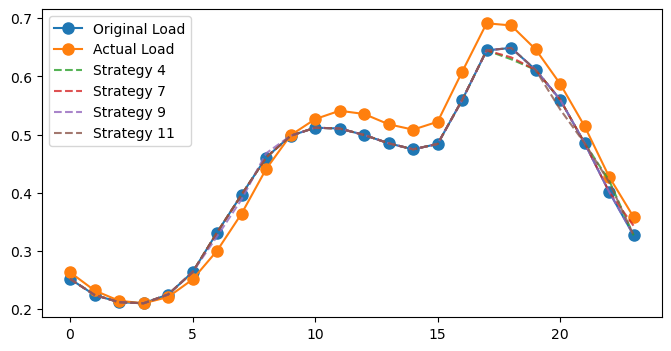

Found 0 relevant failed reflection cases for inquiry 0


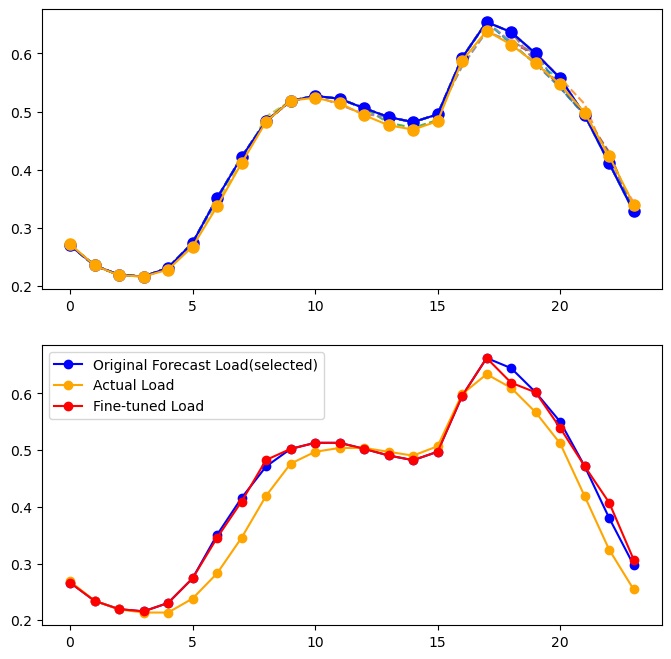

Original cost: 2481.1026357421874, Fine-tuned cost: 2480.900282965845
The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: []
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 2/29
Found 3 similar days for inquiry 1
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
执行策略代码块失败: invalid syntax (<string>, line 1)
No valid strategy functions generated
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_7, cost 2360.04, original cost 2364.13, (reduction 4.08)
Discovered valid strategy strategy_8, cost 2359.57, original cost 2364.13, (reduction 4.55)
Strategy generation attempt #3 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_4, cost 2359.51, original cost 2364.13, (reduction 4.62)
D

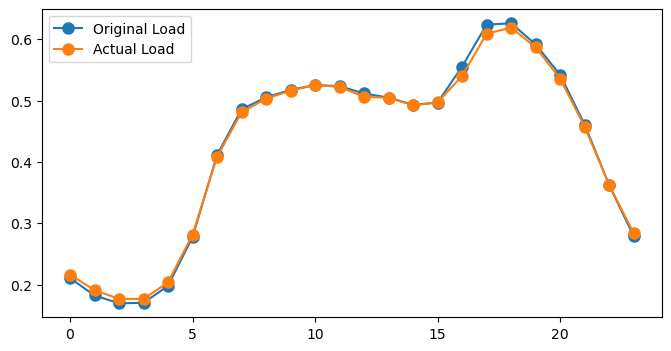

Inquiry 1: No valid strategy found, using original curve as fine-tuned result.
2742.313942138672
2742.2127657505007


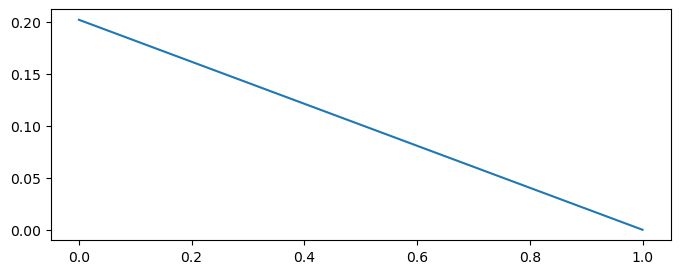

Processing inquiry 3/29
Found 3 similar days for inquiry 2
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_7, cost 2432.05, original cost 2434.63, (reduction 2.58)
Discovered valid strategy strategy_10, cost 2428.99, original cost 2434.63, (reduction 5.64)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_4, cost 2423.06, original cost 2434.63, (reduction 11.57)
Discovered valid strategy strategy_10, cost 2432.70, original cost 2434.63, (reduction 1.93)
Strategy generation attempt #3 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_4, cost 2431.14, original cost 2434.63, (reduction 3.50)
Strategy generation attempt #4 (Current valid strategies: 5/20)
Providing actual load values
Discovered valid strategy strategy_2, cost 2432.02, original cost 2434.63, (reduction 2.61)
Strategy generation

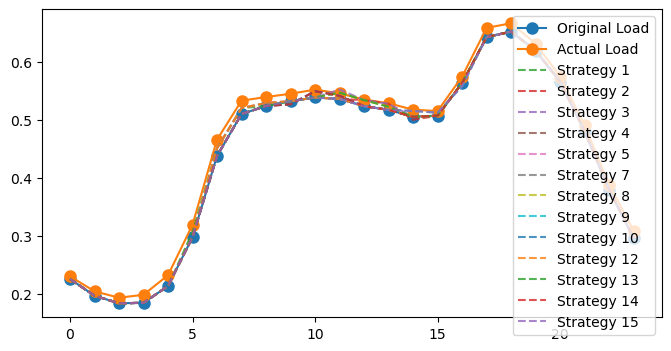

Found 0 relevant failed reflection cases for inquiry 2


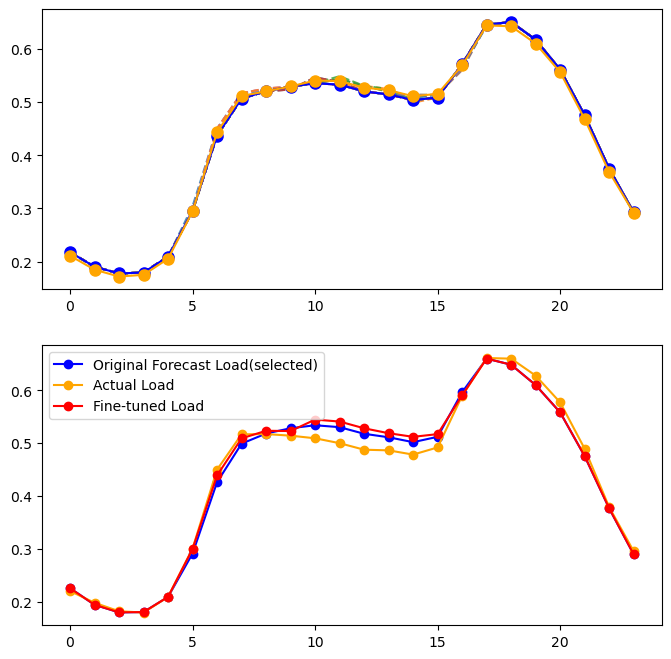

Original cost: 2515.5285556640624, Fine-tuned cost: 2506.048818417093
2666.718813313802
2663.4914499726983


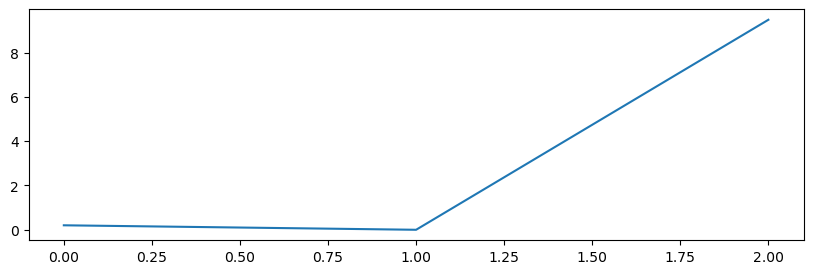

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 4/29
Found 3 similar days for inquiry 3
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
执行策略代码块失败: invalid syntax (<string>, line 1)
No valid strategy functions generated
Strategy generation attempt #3 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #4 (Current valid strategies: 0/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2479.53, original cost 2487.32, (reduction 7.79)
Strategy generation attempt #5 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_9, cost 2475.47, original cost 24

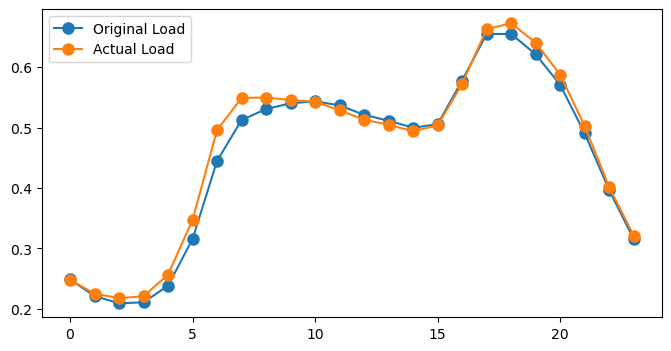

Inquiry 3: No valid strategy found, using original curve as fine-tuned result.
2647.487318237305
2645.066795731477


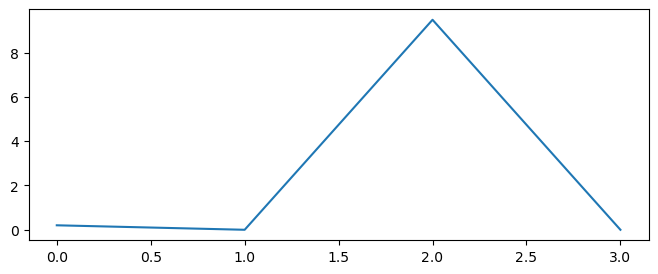

Processing inquiry 5/29
Found 3 similar days for inquiry 4
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_1, cost 2538.15, original cost 2539.65, (reduction 1.51)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_1, cost 2538.15, original cost 2539.65, (reduction 1.51)
Discovered valid strategy strategy_7, cost 2535.35, original cost 2539.65, (reduction 4.31)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_1, cost 2538.15, original cost 2539.65, (reduction 1.51)
Discovered valid strategy strategy_5, cost 2517.79, original cost 2539.65, (reduction 21.87)
Discovered valid strategy strategy_7, cost 2535.35, original cost 2539.65, (reduction 4.31)
Strategy generation attempt #4 (Current valid strategies: 6/20)
Providing actual load values
Discovered valid stra

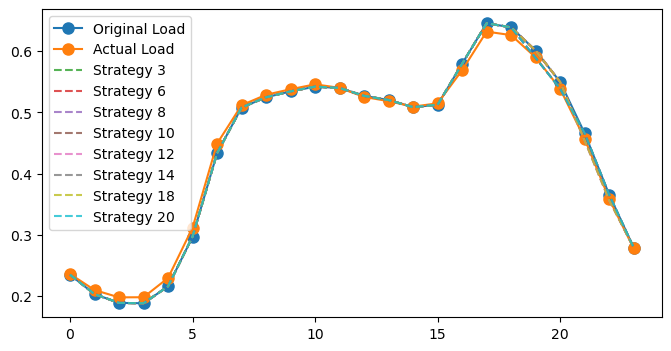

Found 0 relevant failed reflection cases for inquiry 4


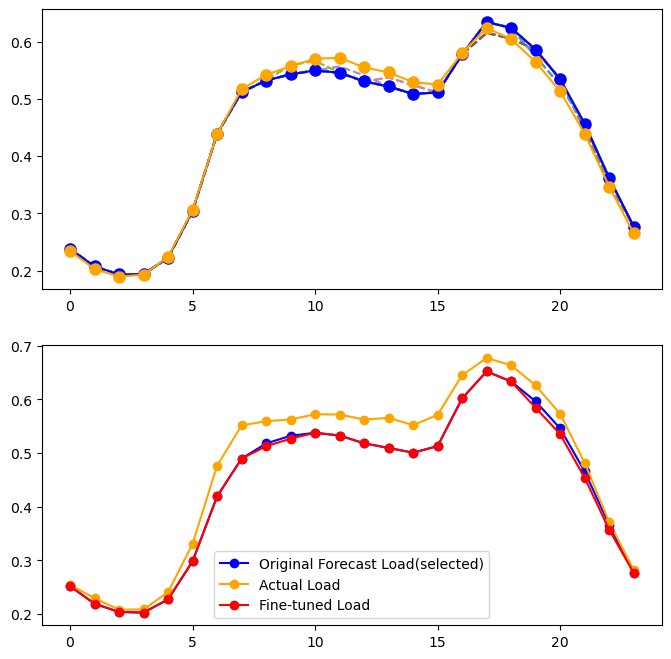

Original cost: 2972.9075268554684, Fine-tuned cost: 3011.26369467269
Strategy generation attempt #1 (Current valid strategies: 0/5)
Discovered valid strategy strategy_2, cost 2964.37, original cost 2972.91, (reduction 8.53)
Discovered valid strategy strategy_6, cost 2963.60, original cost 2972.91, (reduction 9.31)
Discovered valid strategy strategy_10, cost 2956.79, original cost 2972.91, (reduction 16.12)
Strategy generation attempt #2 (Current valid strategies: 3/5)
Providing actual load values
Discovered valid strategy strategy_2, cost 2964.37, original cost 2972.91, (reduction 8.53)
Discovered valid strategy strategy_5, cost 2958.05, original cost 2972.91, (reduction 14.86)
2712.5713599609376
2718.3061755197195


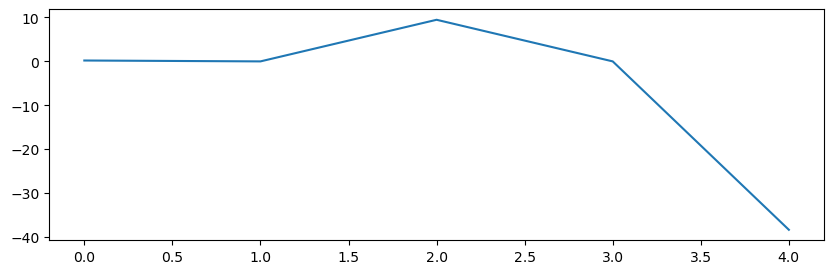

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 6/29
Found 3 similar days for inquiry 5
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
执行策略代码块失败: invalid syntax (<string>, line 1)
No valid strategy functions generated
Strategy generation attempt #3 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #4 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #5 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #6 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #7 (Current valid strategies: 0/20)


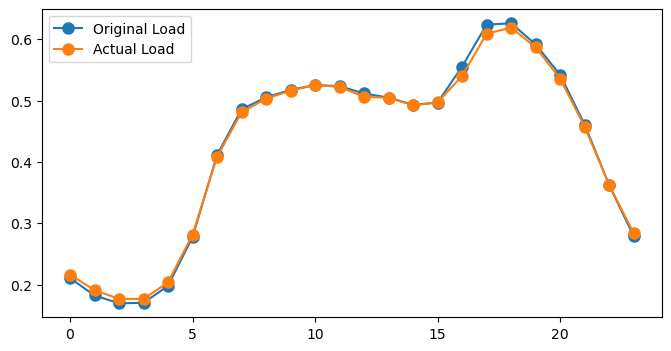

Inquiry 5: No valid strategy found, using original curve as fine-tuned result.
2699.5722212727865
2704.351234238438


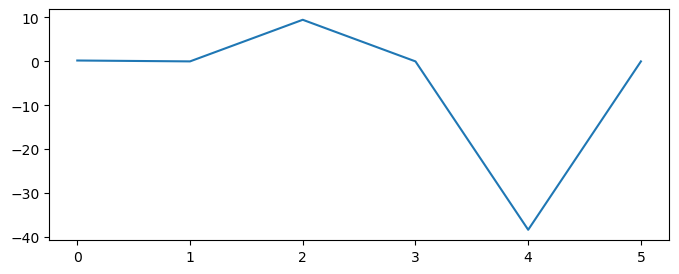

Processing inquiry 7/29
Found 3 similar days for inquiry 6
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_10, cost 2428.75, original cost 2434.37, (reduction 5.62)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Strategy generation attempt #4 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_10, cost 2430.83, original cost 2434.37, (reduction 3.54)
Strategy generation attempt #5 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_6, cost 2428.44, original cost 2434.37, (reduction 5.93)
Discovered valid strategy strategy_9, cost 2427.91, original cost 2434.37, (reduction 6.46)
Strategy generation attempt #6 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid s

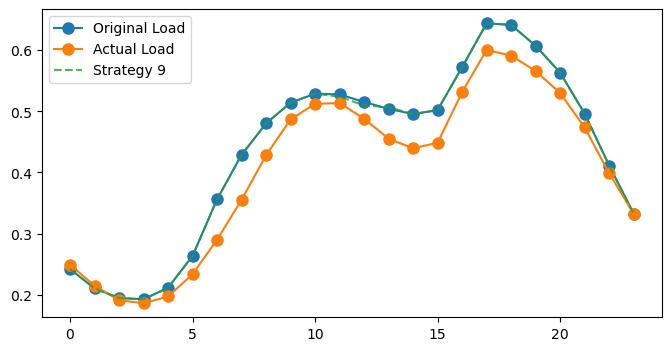

Found 1 relevant failed reflection cases for inquiry 6


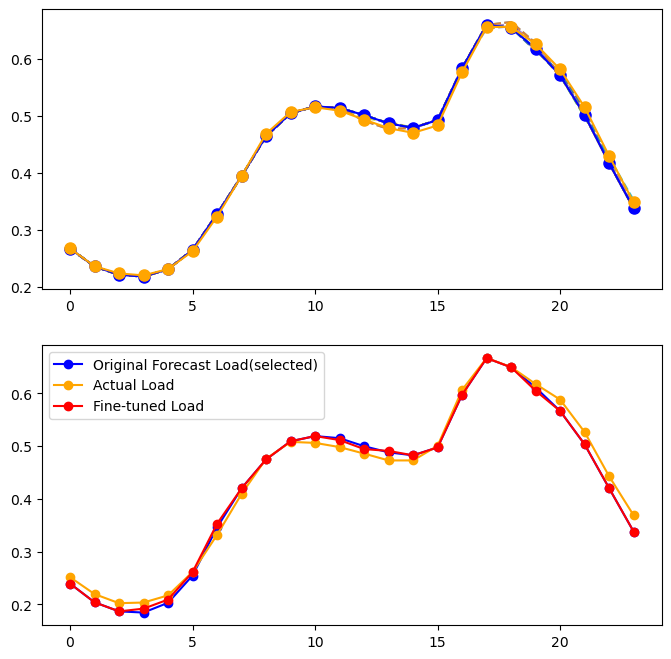

Original cost: 2540.6612573242182, Fine-tuned cost: 2530.9287213117
2676.870654994419
2679.5765895346185


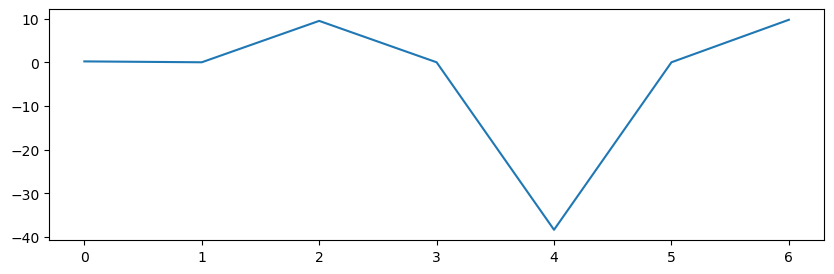

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 8/29
Found 3 similar days for inquiry 7
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_4, cost 2443.73, original cost 2445.55, (reduction 1.82)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Strategy generation attempt #4 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_4, cost 2438.67, original cost 2445.55, (reduction 6.88)
Strategy generation attempt #5 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_4, cost 2438.67, o

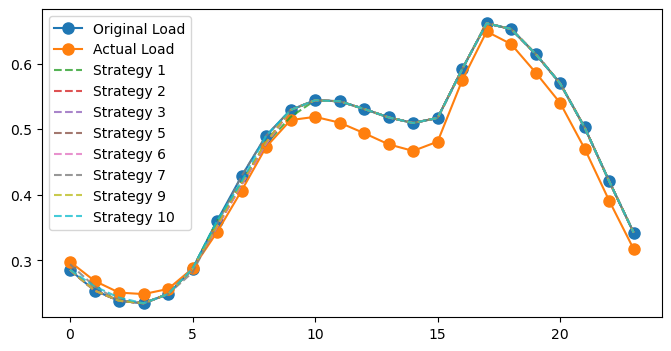

Found 1 relevant failed reflection cases for inquiry 7


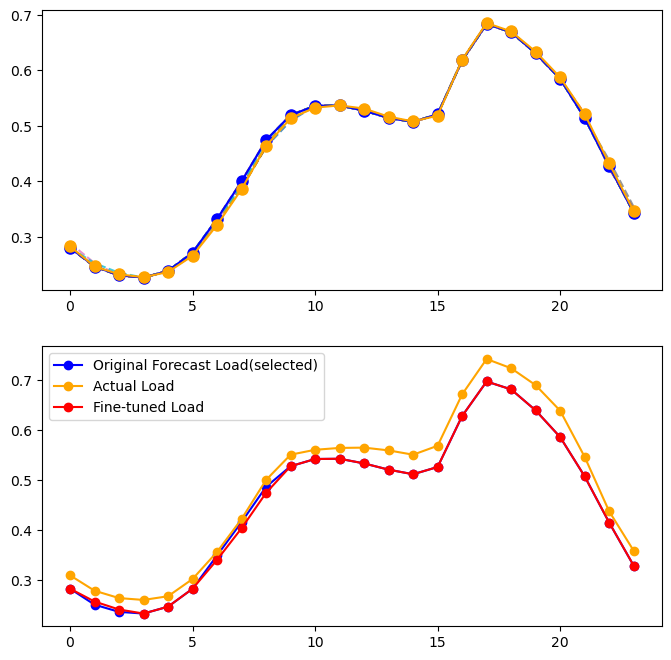

Original cost: 3004.342150878906, Fine-tuned cost: 3020.1969942240266
Strategy generation attempt #1 (Current valid strategies: 0/5)
Discovered valid strategy strategy_2, cost 2985.43, original cost 3004.34, (reduction 18.91)
Discovered valid strategy strategy_6, cost 2974.11, original cost 3004.34, (reduction 30.23)
Discovered valid strategy strategy_10, cost 2970.43, original cost 3004.34, (reduction 33.91)
Strategy generation attempt #2 (Current valid strategies: 3/5)
Providing actual load values
Discovered valid strategy strategy_2, cost 2985.43, original cost 3004.34, (reduction 18.91)
Discovered valid strategy strategy_4, cost 2980.25, original cost 3004.34, (reduction 24.09)
2717.8045919799806
2722.154140120794


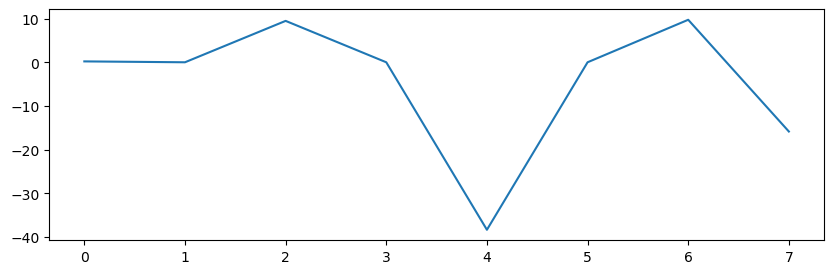

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 9/29
Found 3 similar days for inquiry 8
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_6, cost 2604.00, original cost 2625.02, (reduction 21.02)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_5, cost 2612.58, original cost 2625.02, (reduction 12.44)
Discovered valid strategy strategy_9, cost 2618.80, original cost 2625.02, (reduction 6.22)
Strategy generation attempt #4 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_6, cost 2594.75, 

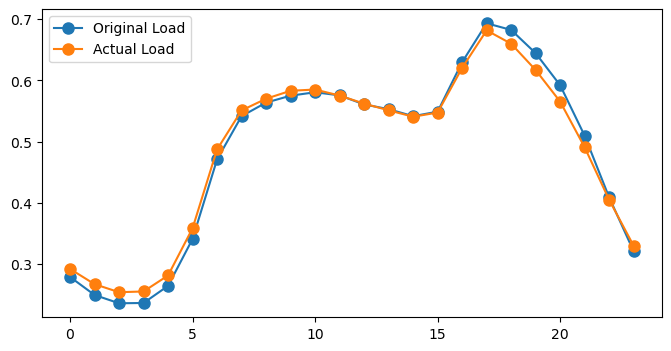

Inquiry 8: No valid strategy found, using original curve as fine-tuned result.
2829.7949978841148
2833.661262898171


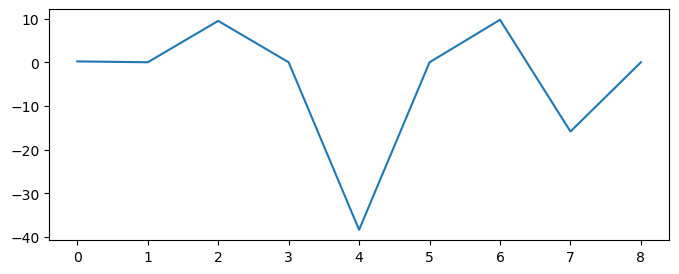

Processing inquiry 10/29
Found 3 similar days for inquiry 9
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_4, cost 2570.59, original cost 2585.09, (reduction 14.50)
Discovered valid strategy strategy_10, cost 2576.03, original cost 2585.09, (reduction 9.06)
Strategy generation attempt #3 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_5, cost 2567.65, original cost 2585.09, (reduction 17.44)
Discovered valid strategy strategy_9, cost 2583.73, original cost 2585.09, (reduction 1.36)
Strategy generation attempt #4 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_3, cost 2572.10, original cost 2585.09, (reduction 12.99)
Discovered valid strategy strategy_5, cost 2576.03, original cost 2585.09, (reduction 9.06)
Discovered valid 

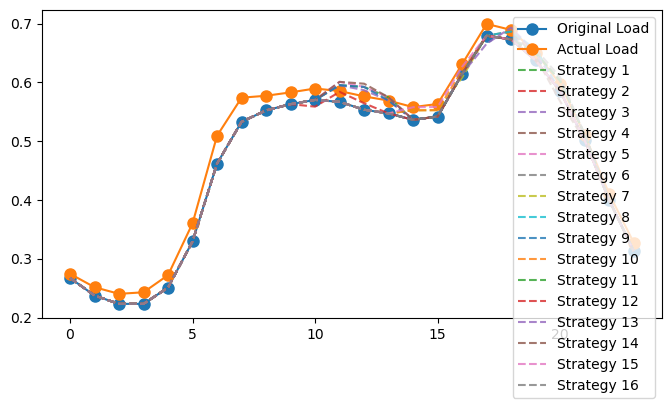

Found 1 relevant failed reflection cases for inquiry 9


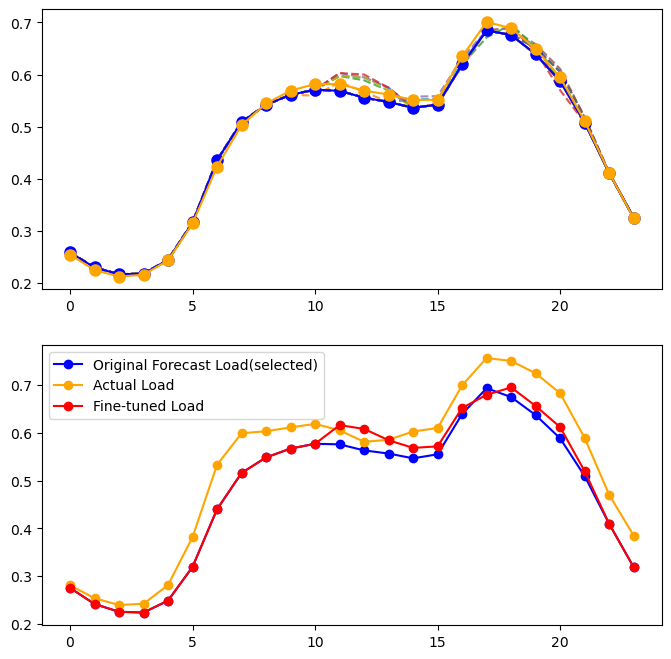

Original cost: 3476.1690576171877, Fine-tuned cost: 3354.7519458392435
2894.432403857422
2885.7703311922787


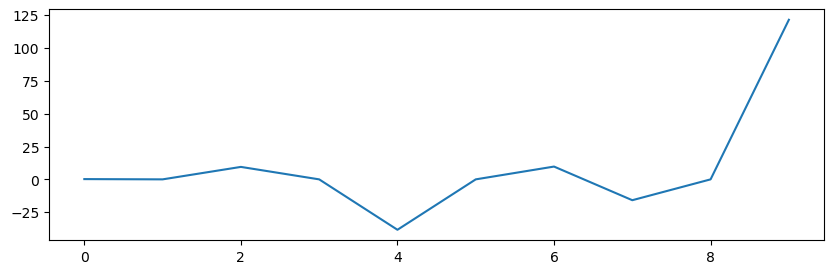

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 11/29
Found 3 similar days for inquiry 10
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_5, cost 2635.08, original cost 2643.86, (reduction 8.78)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_7, cost 2631.59, original cost 2643.86, (reduction 12.27)
Discovered valid strategy strategy_9, cost 2635.08, original cost 2643.86, (reduction 8.78)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_9, cost 2642.84, original cost 2643.86, (reduction 1.03)
Strategy generation attempt #4 (Current valid str

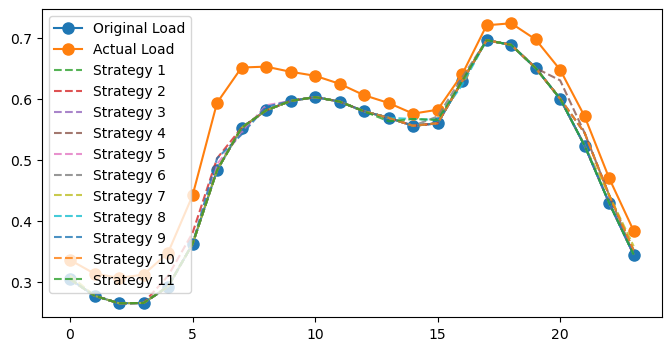

Found 1 relevant failed reflection cases for inquiry 10


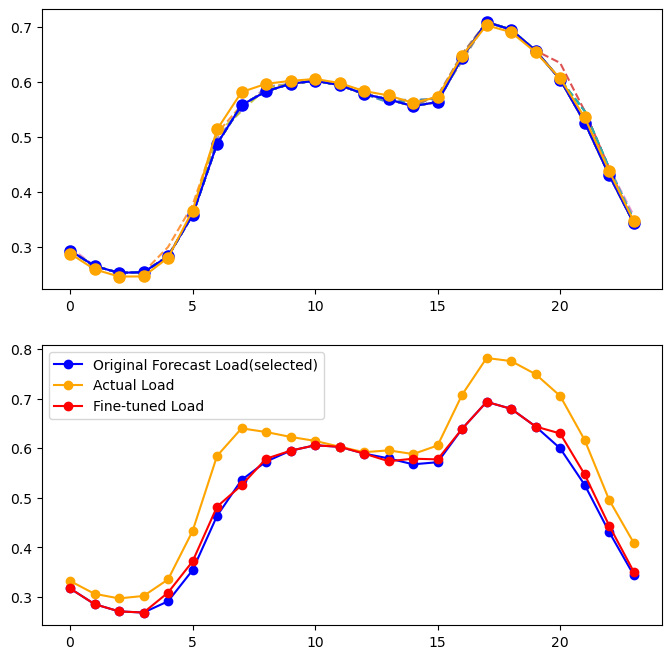

Original cost: 3581.4520034179686, Fine-tuned cost: 3488.5801723412096
2956.8887310901987
2940.5712258421813


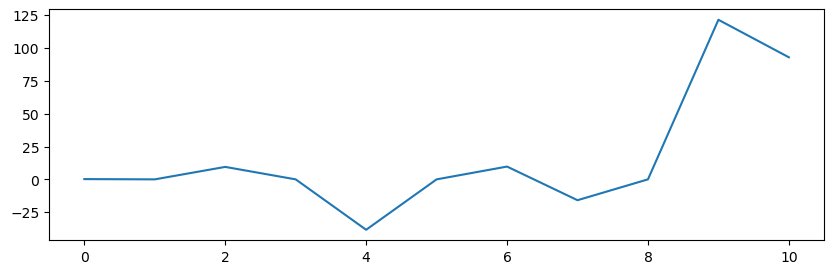

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 12/29
Found 3 similar days for inquiry 11
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_2, cost 2782.65, original cost 2818.63, (reduction 35.97)
Discovered valid strategy strategy_7, cost 2794.26, original cost 2818.63, (reduction 24.37)
Discovered valid strategy strategy_9, cost 2799.40, original cost 2818.63, (reduction 19.23)
Strategy generation attempt #2 (Current valid strategies: 3/20)
Discovered valid strategy strategy_2, cost 2782.65, original cost 2818.63, (reduction 35.97)
Discovered valid strategy strategy_5, cost 2817.21, original cost 2818.63, (reduction 1.42)
Discovered valid strategy strategy_7, cost 2794

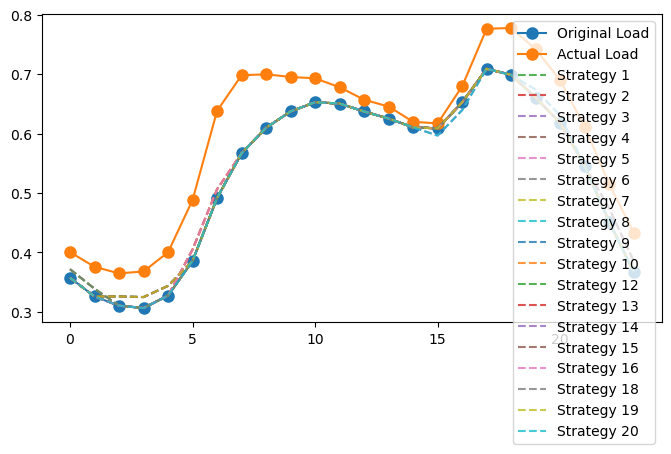

Found 1 relevant failed reflection cases for inquiry 11


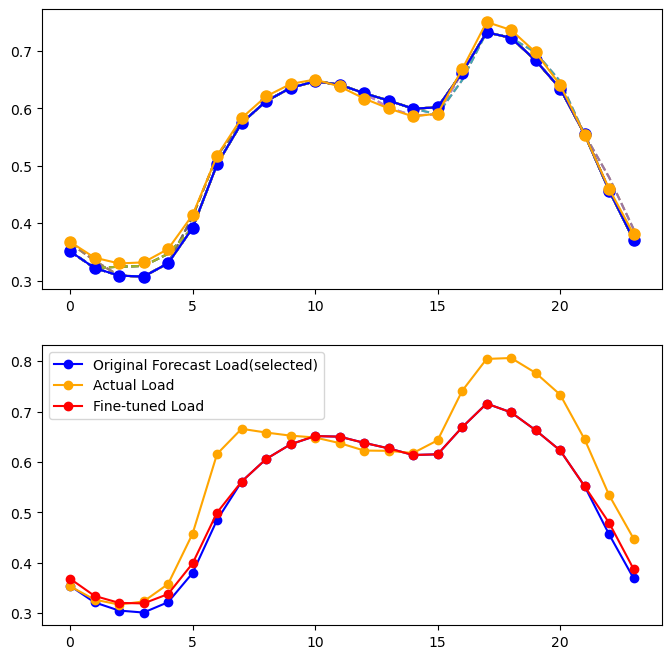

Original cost: 3615.7086518554684, Fine-tuned cost: 3532.2282648349965
3011.790391153971
2989.8759790915824


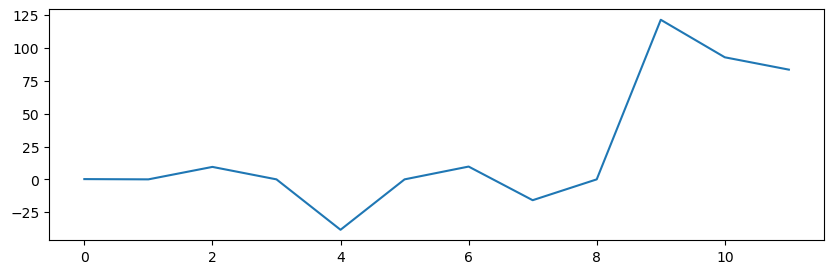

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 13/29
Found 3 similar days for inquiry 12
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_2, cost 2711.67, original cost 2731.33, (reduction 19.66)
Discovered valid strategy strategy_7, cost 2727.41, original cost 2731.33, (reduction 3.92)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_2, cost 2711.67, original cost 2731.33, (reduction 19.66)
Discovered valid strategy strategy_3, cost 2727.40, original cost 2731.33, (reduction 3.93)
Discovered valid strategy strategy_5, cost 2712.83, original cost 2731.33, (reduction 18.51)
Discovered valid strategy strategy_7, cost 2727.

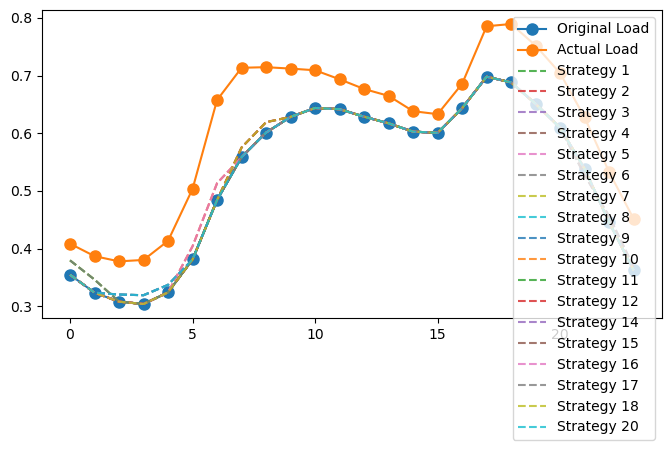

Found 1 relevant failed reflection cases for inquiry 12


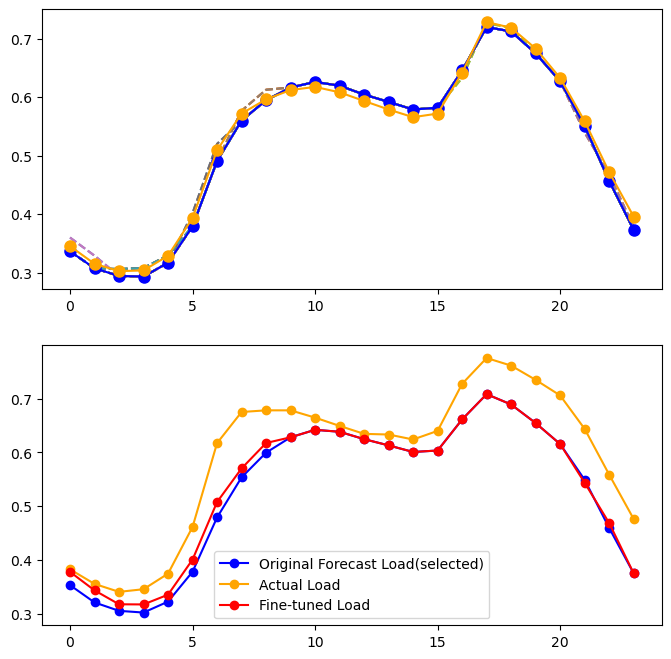

Original cost: 3780.899438476562, Fine-tuned cost: 3654.921604147982
3070.9526255634014
3041.0333348651516


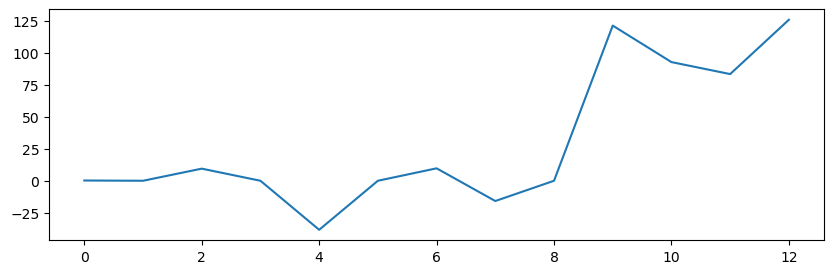

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 14/29
Found 3 similar days for inquiry 13
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_2, cost 2616.76, original cost 2625.46, (reduction 8.70)
Discovered valid strategy strategy_6, cost 2608.12, original cost 2625.46, (reduction 17.34)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_2, cost 2616.76, original cost 2625.46, (reduction 8.70)
Discovered valid strategy strategy_6, cost 2608.12, original cost 2625.46, (reduction 17.34)
Strategy generation attempt #3 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_2, cost 2616.

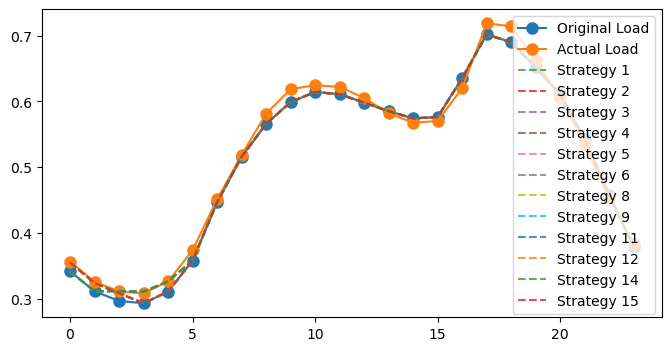

Found 1 relevant failed reflection cases for inquiry 13


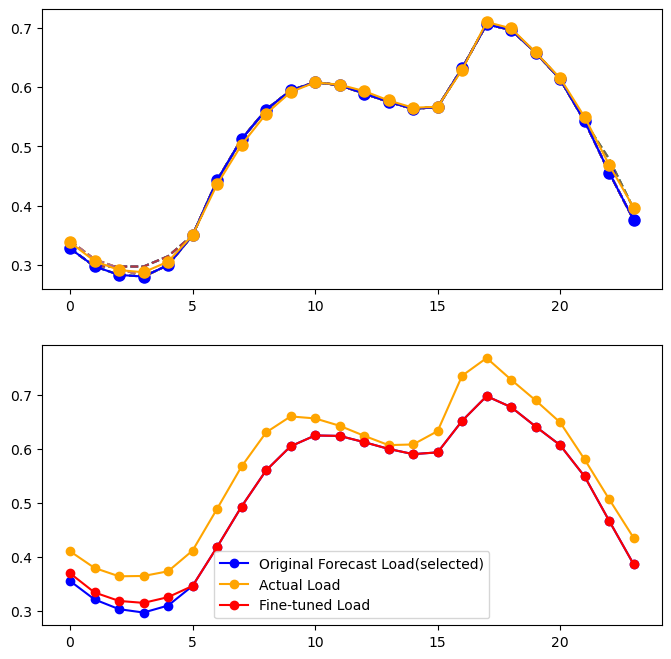

Original cost: 3516.789266113281, Fine-tuned cost: 3462.7563148792983
3102.7980998883927
3071.1564048661617


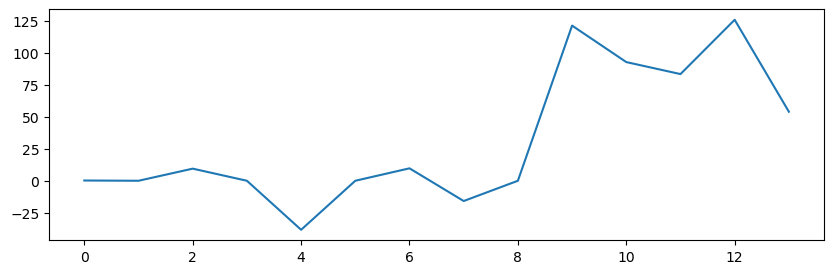

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 15/29
Found 3 similar days for inquiry 14
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_2, cost 2613.17, original cost 2625.46, (reduction 12.29)
Discovered valid strategy strategy_6, cost 2609.05, original cost 2625.46, (reduction 16.41)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_2, cost 2613.17, original cost 2625.46, (reduction 12.29)
Discovered valid strategy strategy_6, cost 2609.05, original cost 2625.46, (reduction 16.41)
Discovered valid strategy strategy_10, cost 2609.77, original cost 2625.46, (reduction 15.69)
Strategy generation attempt #3 (Current valid

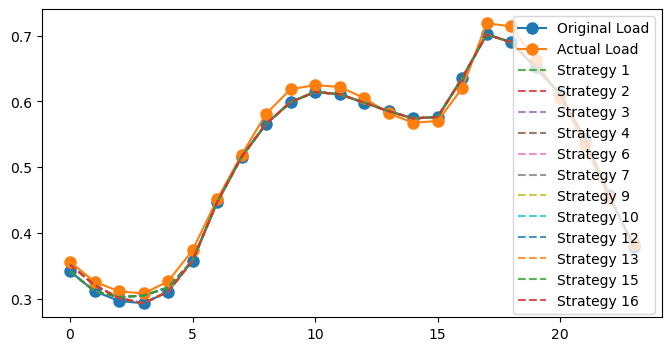

Found 1 relevant failed reflection cases for inquiry 14


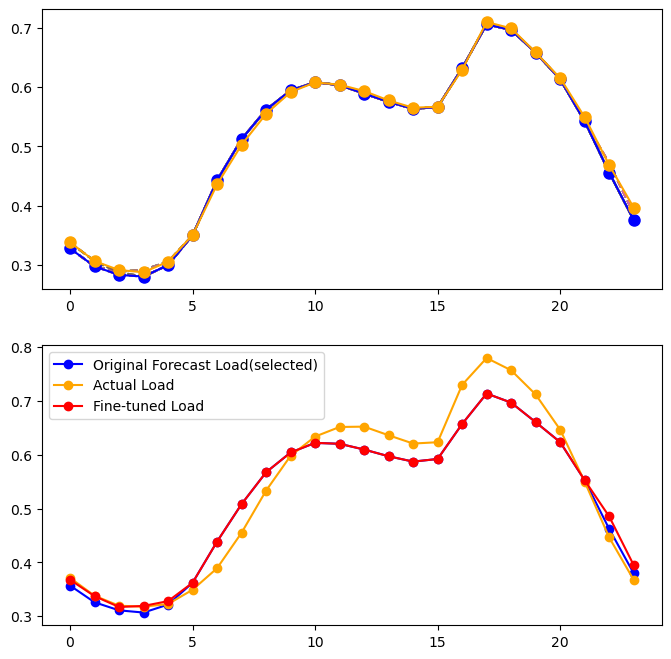

Original cost: 3018.1526723632815, Fine-tuned cost: 3001.2570281893013
3097.155071386718
3066.4964464210375


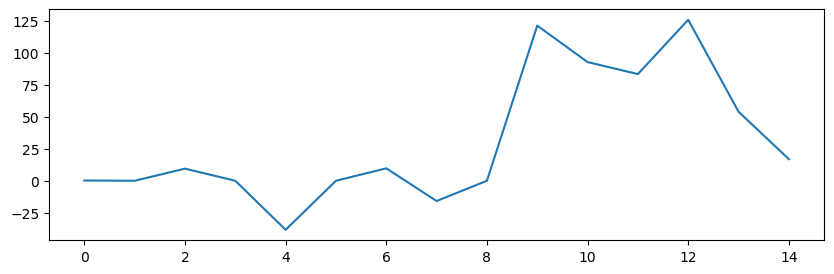

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 16/29
Found 3 similar days for inquiry 15
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Strategy generation attempt #3 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #4 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #5 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #6 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #7 (Current valid strategies: 0/20)
Providing actual load values
Strategy generation attempt #8 (Current valid 

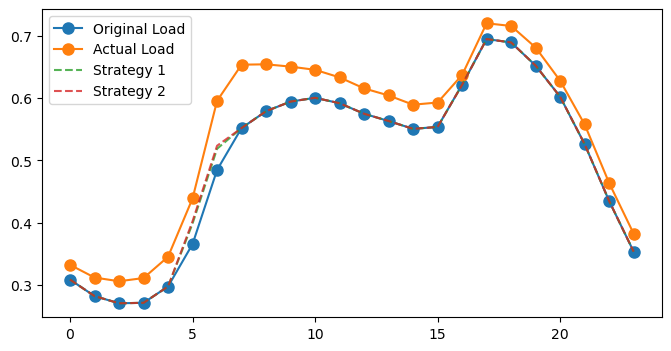

Found 1 relevant failed reflection cases for inquiry 15


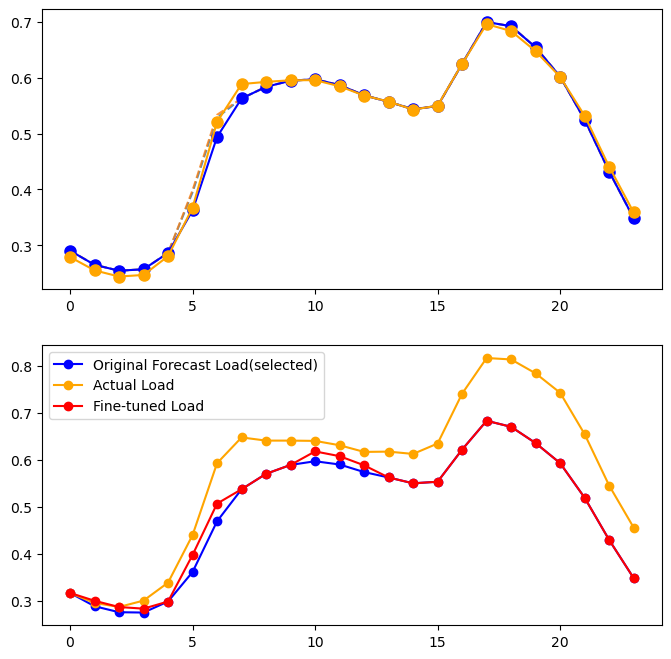

Original cost: 4055.5434125976562, Fine-tuned cost: 3948.0090536583302
3157.054342712402
3121.590984373369


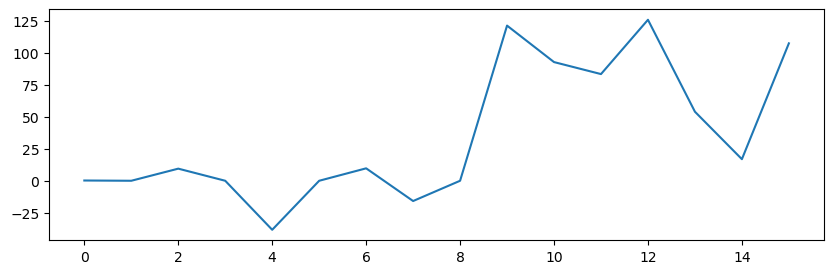

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 17/29
Found 3 similar days for inquiry 16
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
执行策略代码块失败: invalid syntax (<string>, line 3)
No valid strategy functions generated
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_1, cost 2749.56, original cost 2771.35, (reduction 21.79)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_1, cost 2749.56, original cost 2771.35, (reduction 21.79)
Discovered valid strategy strategy_7, cost 2758.66, original cost 2771.35, (reduction 12.69)
Strategy generation attempt #4 (Current valid strategies

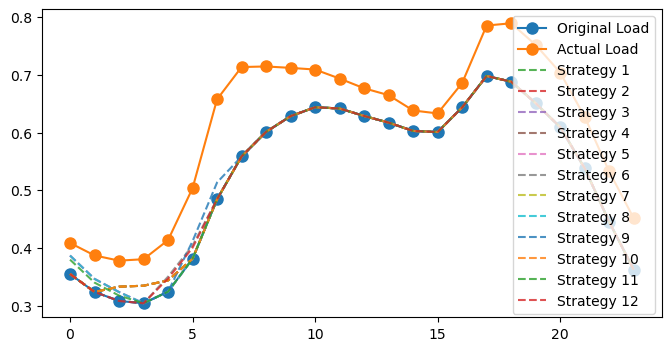

Found 1 relevant failed reflection cases for inquiry 16


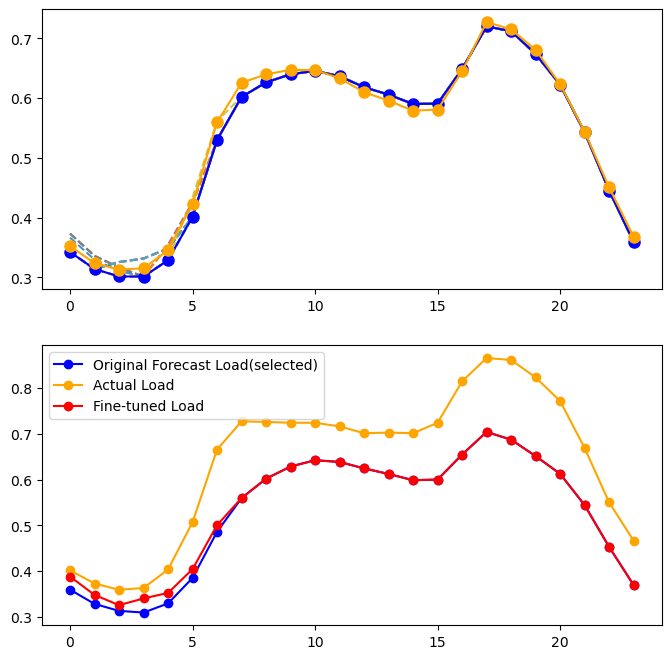

Original cost: 4749.1021367187495, Fine-tuned cost: 4643.062778374013
3250.7042129480697
3211.089325196936


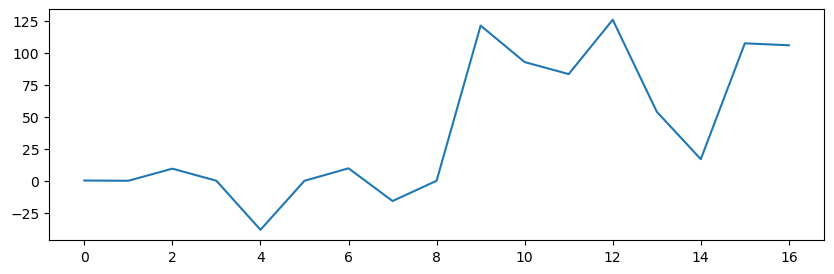

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 18/29
Found 3 similar days for inquiry 17
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_2, cost 2746.43, original cost 2771.35, (reduction 24.92)
Discovered valid strategy strategy_6, cost 2753.47, original cost 2771.35, (reduction 17.88)
Discovered valid strategy strategy_8, cost 2760.90, original cost 2771.35, (reduction 10.45)
Strategy generation attempt #2 (Current valid strategies: 3/20)
Discovered valid strategy strategy_7, cost 2760.20, original cost 2771.35, (reduction 11.15)
Strategy generation attempt #3 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_2, cost 274

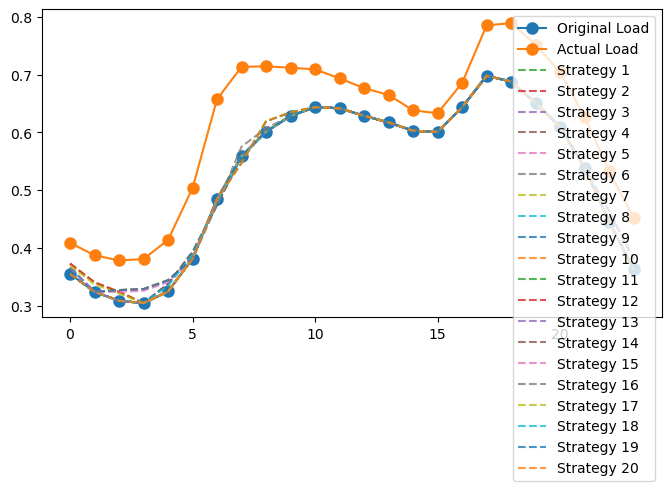

Found 1 relevant failed reflection cases for inquiry 17


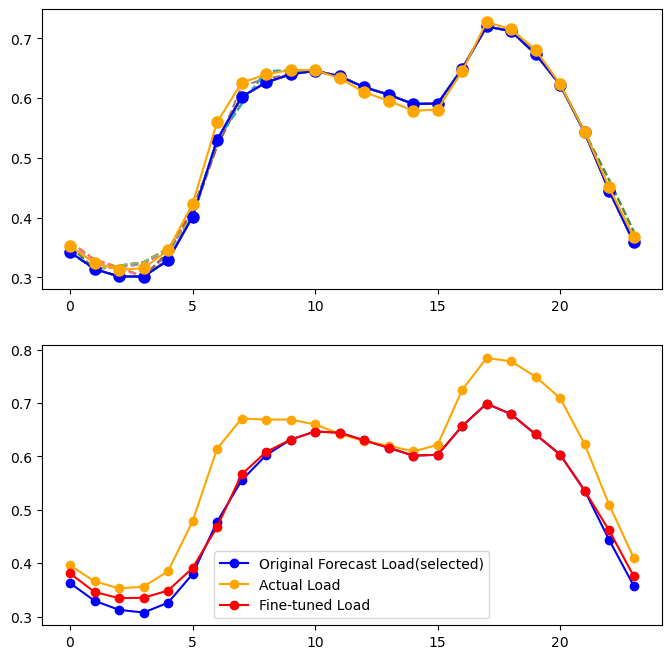

Original cost: 3717.696841796875, Fine-tuned cost: 3602.51231477716
3276.6482478841144
3232.835046840282


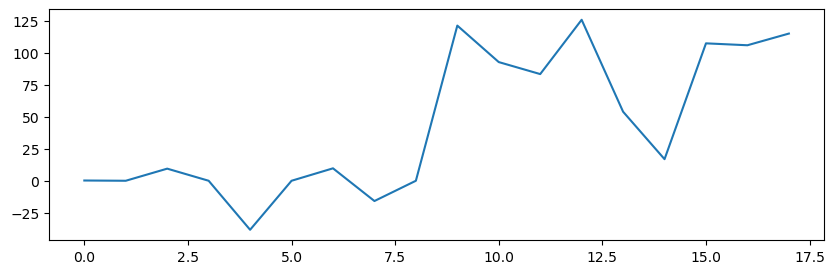

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 19/29
Found 3 similar days for inquiry 18
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_6, cost 2623.00, original cost 2624.36, (reduction 1.36)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_6, cost 2612.75, original cost 2624.36, (reduction 11.61)
Strategy generation attempt #4 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2613.97, original cost 2624.36, (reduction 10.38)
Strategy generation attempt #5 (Current valid s

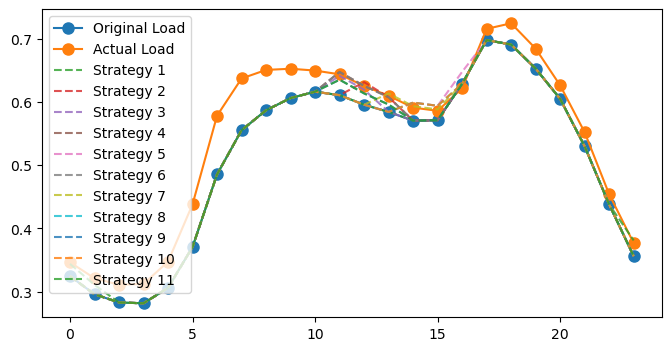

Found 1 relevant failed reflection cases for inquiry 18


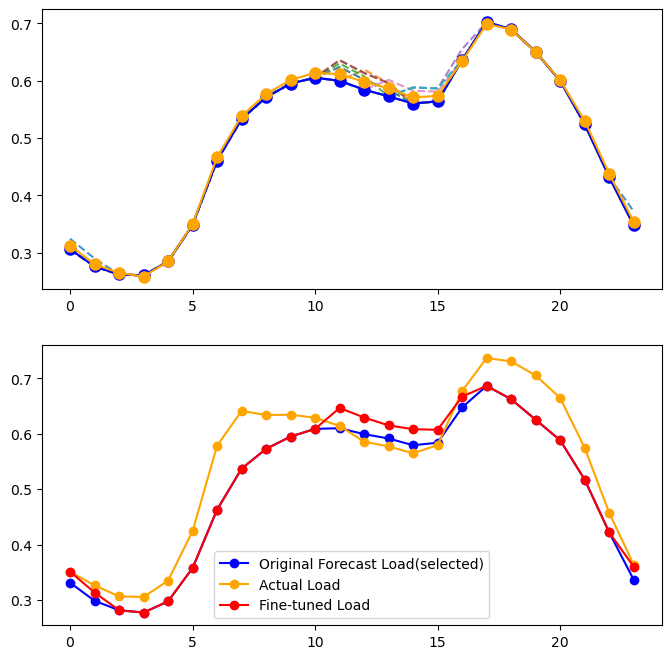

Original cost: 3330.081929199219, Fine-tuned cost: 3308.7637089338004
3279.460546900699
3236.831292213625


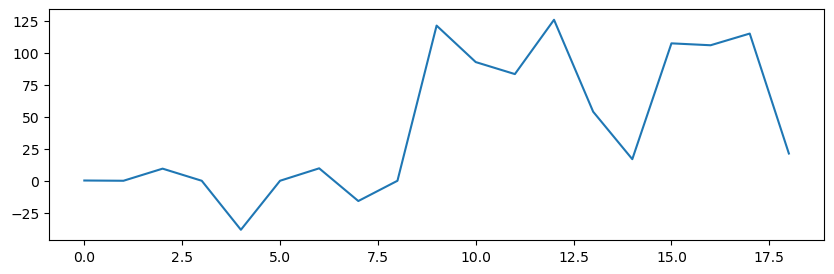

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 20/29
Found 3 similar days for inquiry 19
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_10, cost 2548.22, original cost 2554.99, (reduction 6.76)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_8, cost 2553.41, original cost 2554.99, (reduction 1.58)
Strategy generation attempt #3 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2547.53, original cost 2554.99, (reduction 7.45)
Discovered valid strategy strategy_8, cost 2552.41, original cost 2554.99, (reduction 2.57)
Discovered valid strategy strategy_9, cost 2553.7

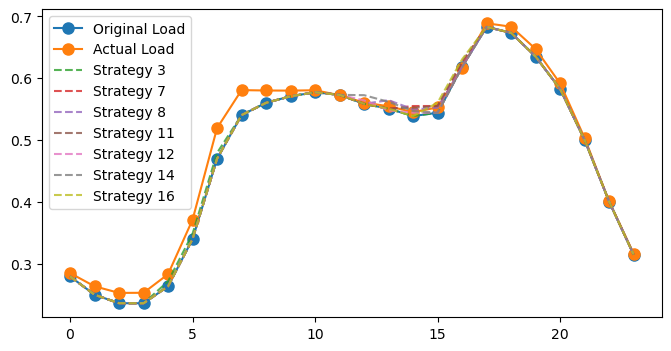

Found 0 relevant failed reflection cases for inquiry 19


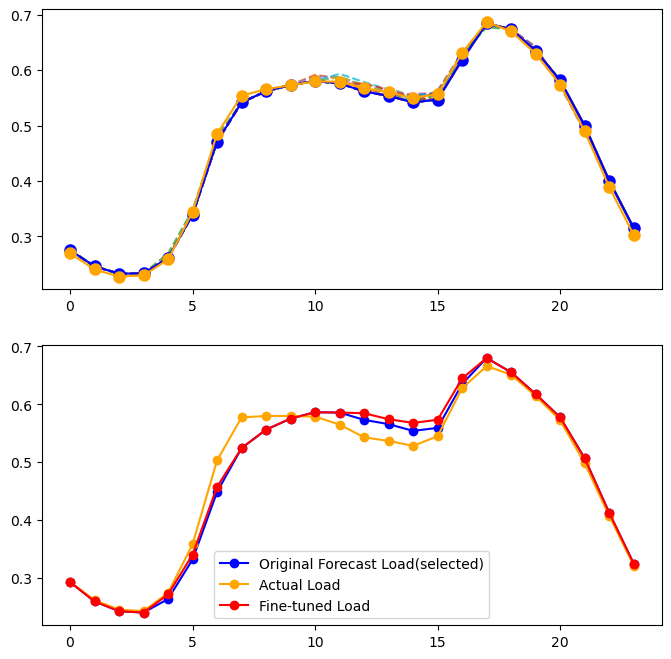

Original cost: 2656.926834472656, Fine-tuned cost: 2654.290402078617
3248.333861279297
3207.7042477068744


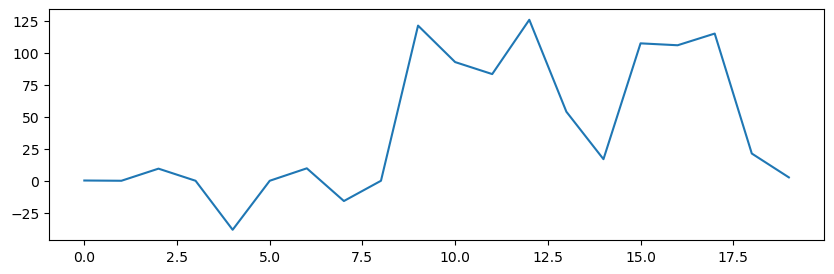

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 21/29
Found 3 similar days for inquiry 20
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_1, cost 2430.73, original cost 2433.29, (reduction 2.56)
Discovered valid strategy strategy_10, cost 2429.28, original cost 2433.29, (reduction 4.01)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_1, cost 2430.73, original cost 2433.29, (reduction 2.56)
Discovered valid strategy strategy_10, cost 2429.28, original cost 2433.29, (reduction 4.01)
Strategy generation attempt #3 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_1, cost 2430.

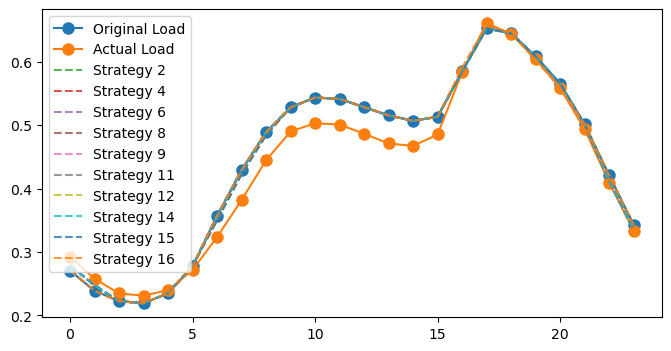

Found 0 relevant failed reflection cases for inquiry 20


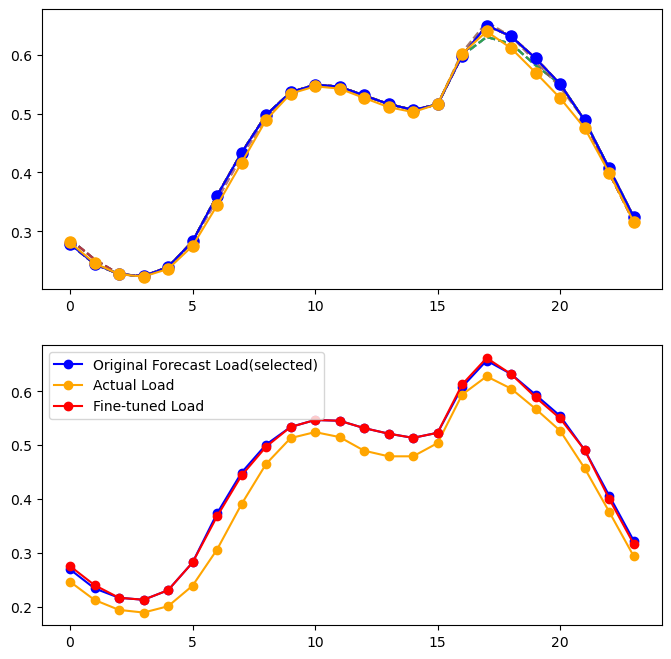

Original cost: 2520.5680385742185, Fine-tuned cost: 2516.614528686392
3213.6783459123885
3174.795213467804


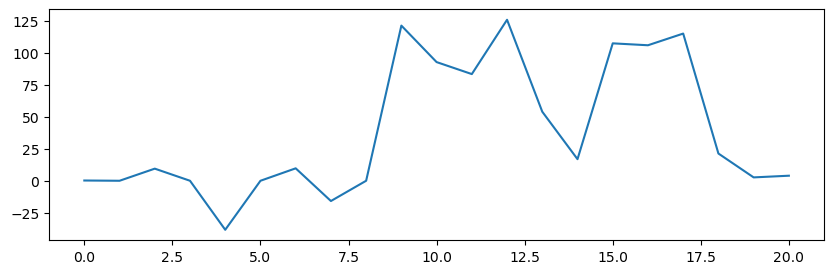

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 22/29
Found 3 similar days for inquiry 21
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_8, cost 2425.74, original cost 2427.11, (reduction 1.38)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_5, cost 2422.46, original cost 2427.11, (reduction 4.65)
Strategy generation attempt #4 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_5, cost 2422.53, original cost 2427.11, (reduction 4.58)
Discovered valid strategy strategy_10, cost 2424.

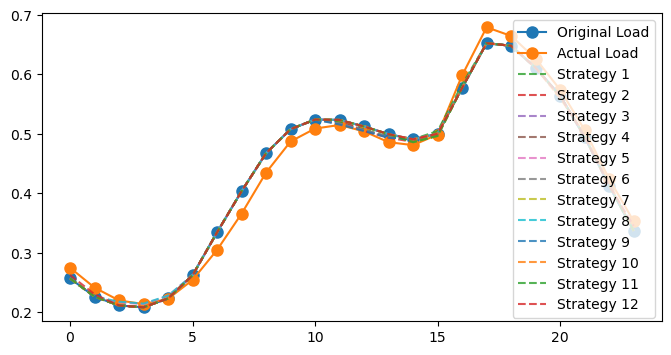

Found 0 relevant failed reflection cases for inquiry 21


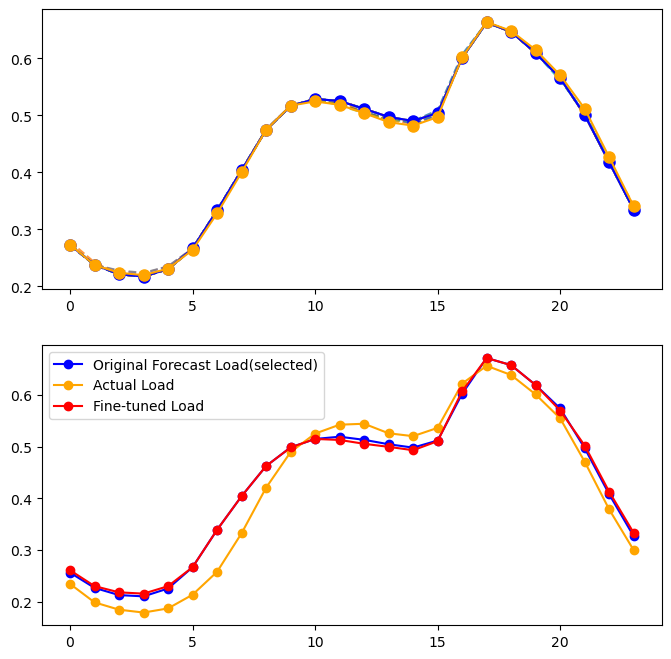

Original cost: 2590.011978027344, Fine-tuned cost: 2613.7098504406727
Strategy generation attempt #1 (Current valid strategies: 0/5)
Discovered valid strategy strategy_1, cost 2580.89, original cost 2590.01, (reduction 9.12)
Discovered valid strategy strategy_6, cost 2584.92, original cost 2590.01, (reduction 5.09)
Discovered valid strategy strategy_7, cost 2583.36, original cost 2590.01, (reduction 6.66)
Strategy generation attempt #2 (Current valid strategies: 3/5)
Providing actual load values
Discovered valid strategy strategy_4, cost 2585.47, original cost 2590.01, (reduction 4.54)
Strategy generation attempt #3 (Current valid strategies: 4/5)
Providing actual load values
3185.329874644886
3149.291333330207


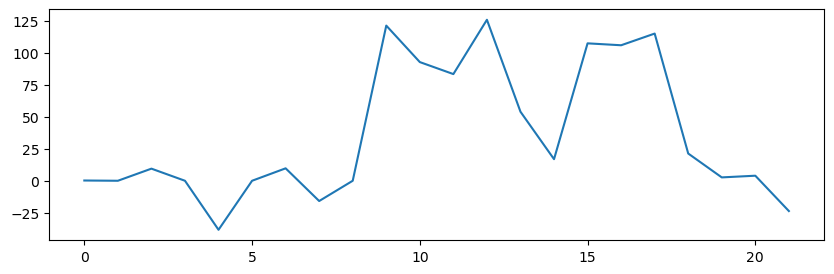

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 23/29
Found 3 similar days for inquiry 22
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Strategy generation attempt #3 (Current valid strategies: 0/20)
Providing actual load values
Discovered valid strategy strategy_8, cost 2546.38, original cost 2551.16, (reduction 4.78)
Strategy generation attempt #4 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_6, cost 2546.16, original cost 2551.16, (reduction 5.00)
Strategy generation attempt #5 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_3, cost 2549.

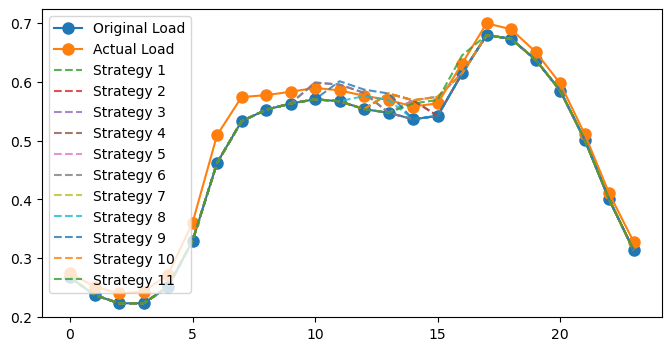

Found 1 relevant failed reflection cases for inquiry 22


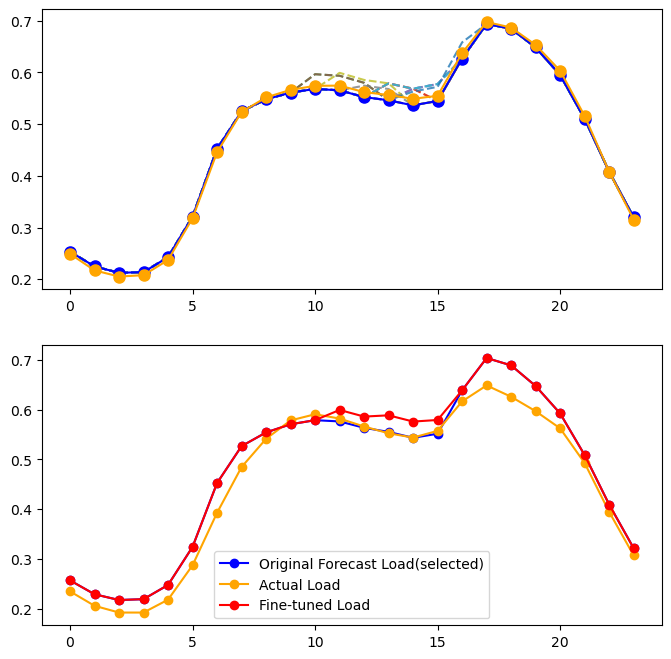

Original cost: 2590.4960615234377, Fine-tuned cost: 2613.320269543779
Strategy generation attempt #1 (Current valid strategies: 0/5)
Discovered valid strategy strategy_1, cost 2558.87, original cost 2590.50, (reduction 31.63)
Discovered valid strategy strategy_8, cost 2587.82, original cost 2590.50, (reduction 2.68)
Strategy generation attempt #2 (Current valid strategies: 2/5)
Providing actual load values
Discovered valid strategy strategy_1, cost 2558.87, original cost 2590.50, (reduction 31.63)
Discovered valid strategy strategy_7, cost 2570.84, original cost 2590.50, (reduction 19.65)
Discovered valid strategy strategy_10, cost 2584.90, original cost 2590.50, (reduction 5.59)
3159.467534943953
3125.9882436003622


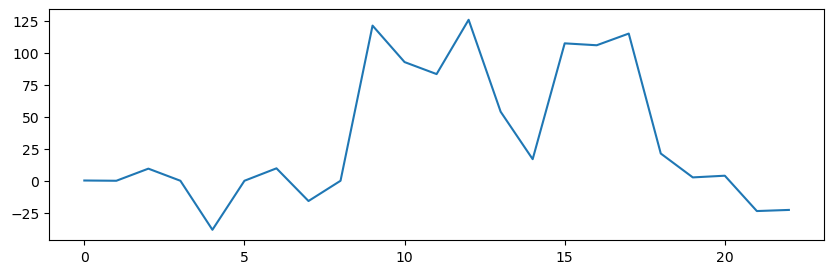

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 24/29
Found 3 similar days for inquiry 23
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Strategy generation attempt #2 (Current valid strategies: 0/20)
Discovered valid strategy strategy_7, cost 2550.36, original cost 2565.34, (reduction 14.98)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2550.36, original cost 2565.34, (reduction 14.98)
Strategy generation attempt #4 (Current valid strategies: 2/20)
Providing actual load values
Discovered valid strategy strategy_5, cost 2563.17, original cost 2565.34, (reduction 2.17)
Discovered valid strategy strategy_7, cost 2550

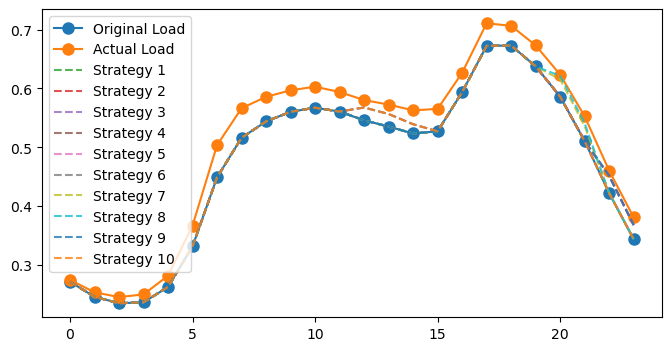

Found 1 relevant failed reflection cases for inquiry 23


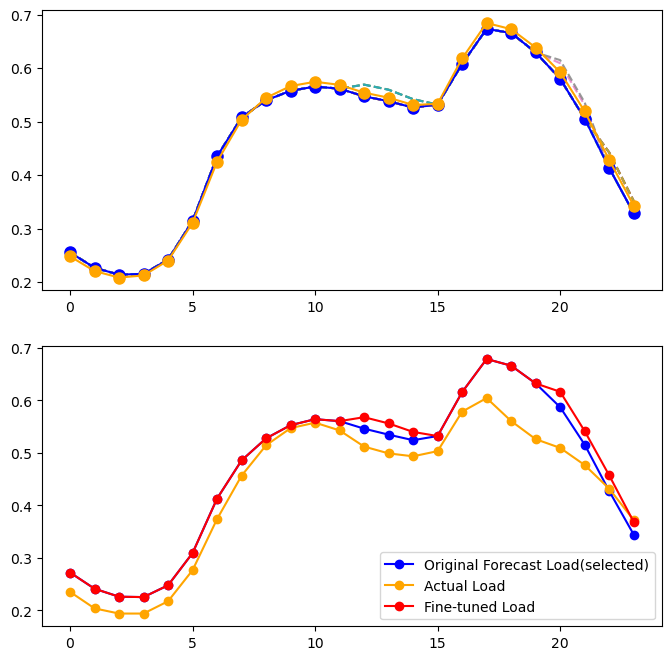

Original cost: 2616.2600766601568, Fine-tuned cost: 2633.019929952952
Strategy generation attempt #1 (Current valid strategies: 0/5)
Discovered valid strategy strategy_1, cost 2602.66, original cost 2616.26, (reduction 13.60)
Discovered valid strategy strategy_6, cost 2609.37, original cost 2616.26, (reduction 6.89)
Discovered valid strategy strategy_8, cost 2607.62, original cost 2616.26, (reduction 8.64)
Discovered valid strategy strategy_9, cost 2614.84, original cost 2616.26, (reduction 1.42)
Strategy generation attempt #2 (Current valid strategies: 4/5)
Providing actual load values
Discovered valid strategy strategy_1, cost 2602.66, original cost 2616.26, (reduction 13.60)
3136.8338908487954
3105.4478971983867


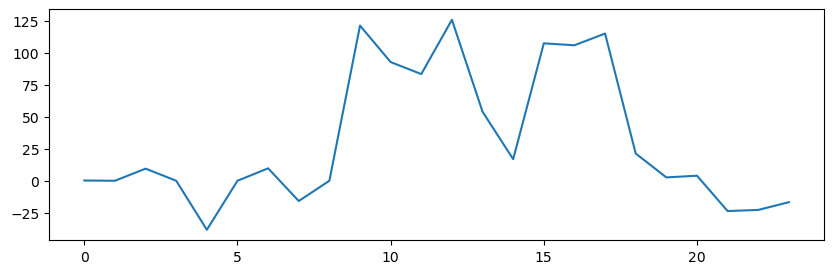

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 25/29
Found 3 similar days for inquiry 24
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_7, cost 2452.41, original cost 2460.43, (reduction 8.02)
Discovered valid strategy strategy_9, cost 2457.77, original cost 2460.43, (reduction 2.66)
Strategy generation attempt #2 (Current valid strategies: 2/20)
Discovered valid strategy strategy_1, cost 2458.42, original cost 2460.43, (reduction 2.01)
Discovered valid strategy strategy_7, cost 2454.30, original cost 2460.43, (reduction 6.13)
Strategy generation attempt #3 (Current valid strategies: 4/20)
Providing actual load values
Discovered valid strategy strategy_1, cost 2458.42

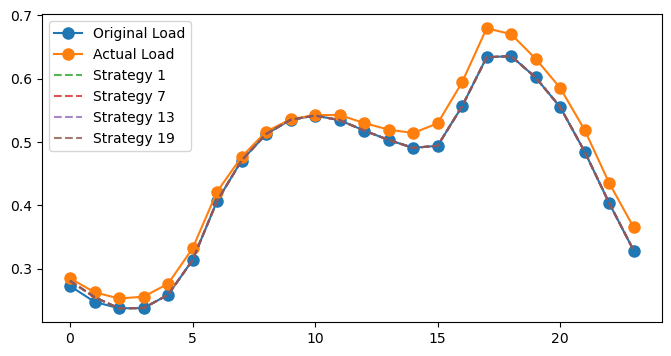

Found 1 relevant failed reflection cases for inquiry 24


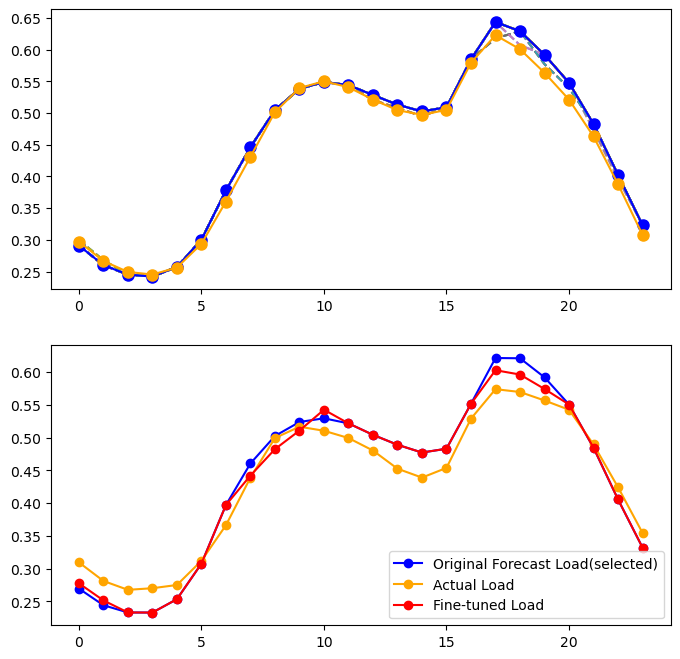

Original cost: 2624.911008789062, Fine-tuned cost: 2609.6200057704536
3116.356975566406
3085.6147815412696


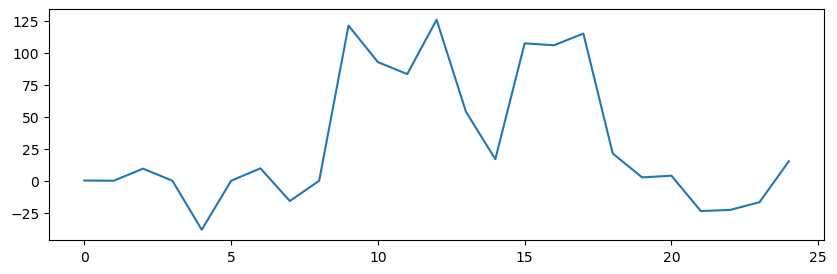

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 26/29
Found 3 similar days for inquiry 25
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_1, cost 2444.78, original cost 2446.46, (reduction 1.68)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_1, cost 2444.78, original cost 2446.46, (reduction 1.68)
Discovered valid strategy strategy_5, cost 2440.46, original cost 2446.46, (reduction 6.00)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_1, cost 2444.78, original cost 2446.46, (reduction 1.68)
Discovered valid strategy strategy_5, cost 2440.46

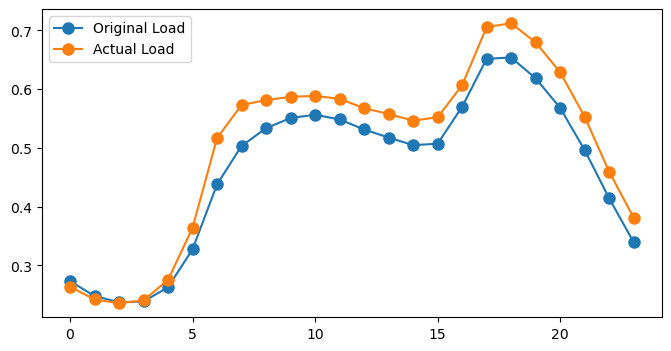

Inquiry 25: No valid strategy found, using original curve as fine-tuned result.
3153.285051626352
3123.725249679105


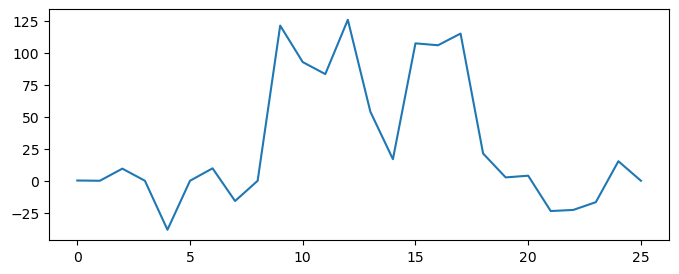

Processing inquiry 27/29
Found 3 similar days for inquiry 26
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_8, cost 2677.76, original cost 2689.65, (reduction 11.89)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_5, cost 2686.22, original cost 2689.65, (reduction 3.42)
Discovered valid strategy strategy_8, cost 2677.76, original cost 2689.65, (reduction 11.89)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_4, cost 2684.06, original cost 2689.65, (reduction 5.59)
Discovered valid strategy strategy_6, cost 2682.74, original cost 2689.65, (reduction 6.91)
Discovered valid strategy strategy_10, cost 2663.15, original cost 2689.65, (reduction 26.49)
Strategy generation attempt #4 (Current valid strategies: 6/20)
Providing actual load values
Discovered valid

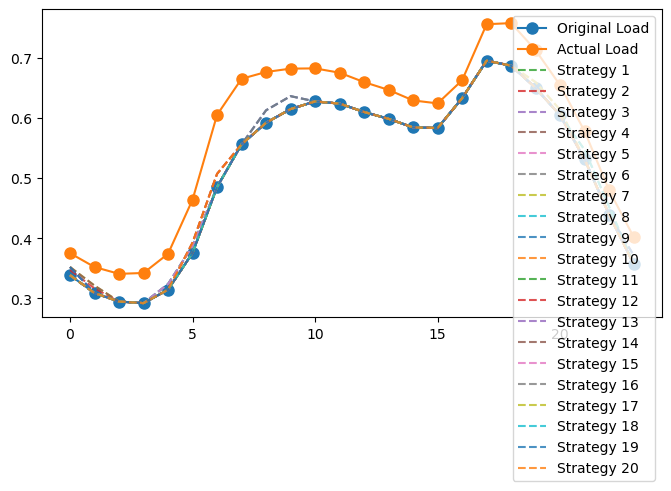

Found 1 relevant failed reflection cases for inquiry 26


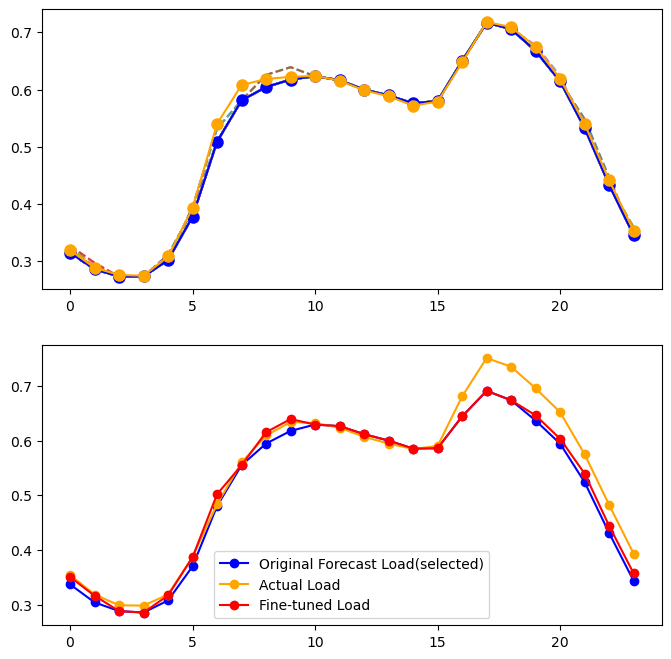

Original cost: 3011.4944169921873, Fine-tuned cost: 2915.128302262179
3148.0335466399015
3115.999436811812


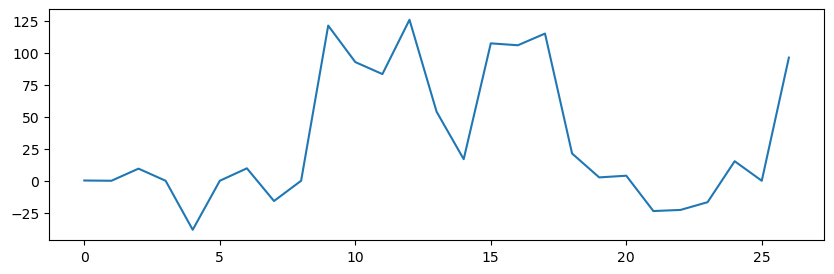

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8, 25]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []
Processing inquiry 28/29
Found 3 similar days for inquiry 27
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_4, cost 2562.22, original cost 2566.03, (reduction 3.80)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Strategy generation attempt #3 (Current valid strategies: 1/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2563.59, original cost 2566.03, (reduction 2.43)
Discovered valid strategy strategy_9, cost 2550.19, original cost 2566.03, (reduction 15.84)
Strategy generation attempt #4 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_3, cost 2

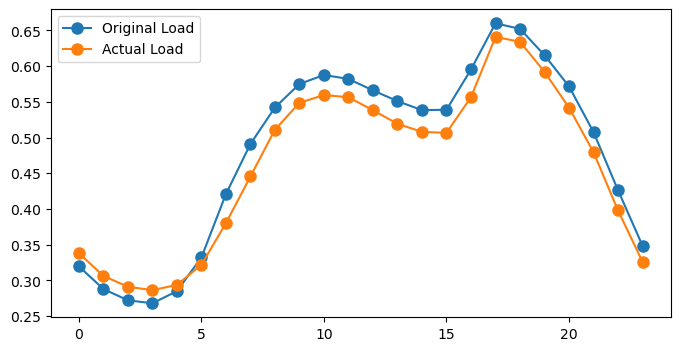

Inquiry 27: No valid strategy found, using original curve as fine-tuned result.
3130.032154209682
3099.1421197325953


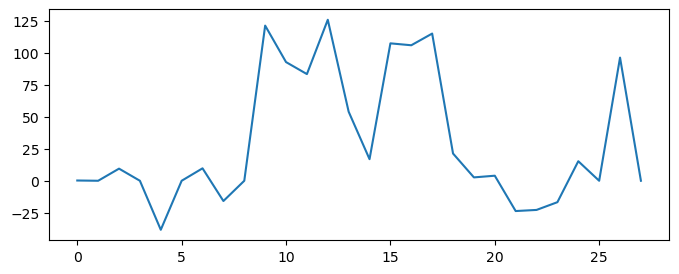

Processing inquiry 29/29
Found 3 similar days for inquiry 28
Generating few-shot prompts based on similar days...
Strategy generation attempt #1 (Current valid strategies: 0/20)
Discovered valid strategy strategy_6, cost 2430.01, original cost 2434.37, (reduction 4.37)
Strategy generation attempt #2 (Current valid strategies: 1/20)
Discovered valid strategy strategy_6, cost 2430.01, original cost 2434.37, (reduction 4.37)
Discovered valid strategy strategy_7, cost 2420.71, original cost 2434.37, (reduction 13.66)
Strategy generation attempt #3 (Current valid strategies: 3/20)
Providing actual load values
Discovered valid strategy strategy_7, cost 2421.47, original cost 2434.37, (reduction 12.90)
Discovered valid strategy strategy_10, cost 2430.79, original cost 2434.37, (reduction 3.58)
Strategy generation attempt #4 (Current valid strategies: 5/20)
Providing actual load values
Discovered valid strategy strategy_8, cost 2422.41, original cost 2434.37, (reduction 11.96)
Discovered valid

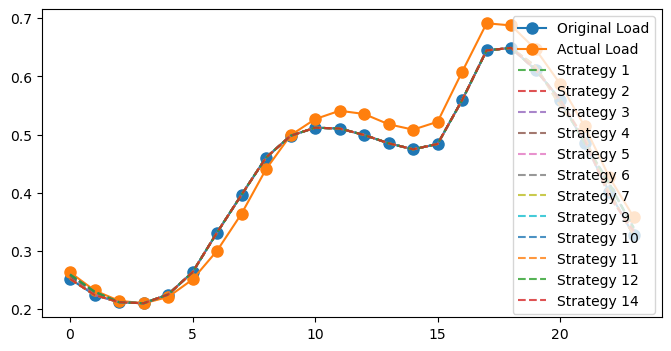

Found 1 relevant failed reflection cases for inquiry 28


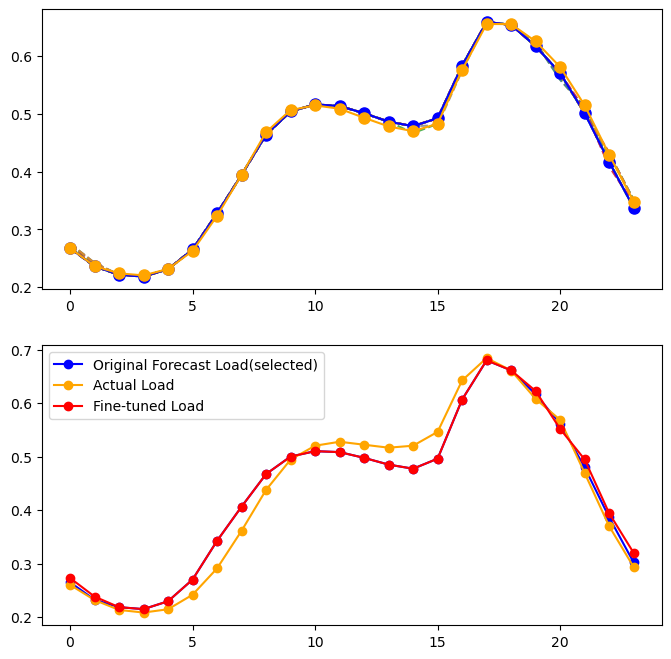

Original cost: 2586.225931152344, Fine-tuned cost: 2609.215912329054
Strategy generation attempt #1 (Current valid strategies: 0/5)
Strategy generation attempt #2 (Current valid strategies: 0/5)
Providing actual load values
Discovered valid strategy strategy_3, cost 2583.43, original cost 2586.23, (reduction 2.80)
Strategy generation attempt #3 (Current valid strategies: 1/5)
Providing actual load values
Discovered valid strategy strategy_5, cost 2580.92, original cost 2586.23, (reduction 5.31)
Strategy generation attempt #4 (Current valid strategies: 2/5)
Providing actual load values
Strategy generation attempt #5 (Current valid strategies: 2/5)
Providing actual load values
Strategy generation attempt #6 (Current valid strategies: 2/5)
Providing actual load values
Strategy generation attempt #7 (Current valid strategies: 2/5)
Providing actual load values
Strategy generation attempt #8 (Current valid strategies: 2/5)
Providing actual load values
Strategy generation attempt #9 (Current 

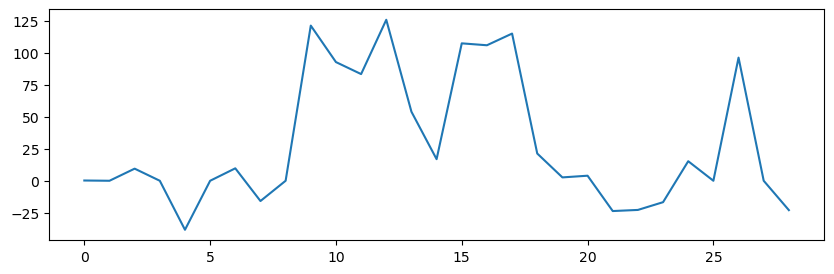

The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: [1, 3, 5, 8, 25, 27]
The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: []


In [ ]:
fine_tuned_result_given_by_LLM = {
    'selected_flag': [], 'original_load': [], 'optnet_load': [], 'fine_tuned_load': [], 
    'cost_org': [], 'cost_optnet': [], 'cost_after': [], 'actual_load': [],
    'few_shot_curves': [], 'few_shot_costs': [], 'few_shot_code': [], 
    'similar_load': [], 'similar_actual_load': [], 'strategy_code': []
}

skip_samples = []
validate_failures = []
reflection_records = []

for inqure_id in range(len(forecasts_load_test_insert)):
    print(f"Processing inquiry {inqure_id+1}/{len(forecasts_load_test_insert)}")
    data_for_inqure = {
        'load': forecasts_load_test_insert[inqure_id],
    }

    similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
    average_similar_load_org = np.mean([day['load'] for day in similar_days], axis=0)
    average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
    average_similar_load_org_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_org).reshape(1,-1))[0]
    average_similar_load_actual_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual).reshape(1,-1))[0]
    _, _, obj_org_similar_days = optimization_module.forward(average_similar_load_org_numpy, average_similar_load_actual_numpy)
    obj_org_similar_days = obj_org_similar_days.item()

    selected_flag = 'org'
    load_nor = data_for_inqure['load']
    average_similar_load = average_similar_load_org
    actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert[inqure_id]).reshape(1,-1))[0]
    load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    higher_flag = "higher" if sum(np.array(average_similar_load) - np.array(average_similar_load_actual)) > 0 else "lower"
    reduce_flag = "reduce" if higher_flag == "higher" else "increase"
    print(f"Found {len(similar_days)} similar days for inquiry {inqure_id}")
    
    system_prompt = generate_prompt_sys(args, data_for_inqure)

    full_user_prompt = f"SYSTEM INSTRUCTIONS:\n{system_prompt}."
    full_user_prompt += f"""\n\nHint: You have two approaches to reduce cost:  

    1. Compare the actual value and forecast of the similar day, try to learn some error reduction strategies. In historical similar days, we found the forecasts were {higher_flag} than actual, so you can try to {reduce_flag} the load in some hours to reduce cost.  
    2. Compare the future positive and negative reserve prices.  
    - If the positive reserve price is much higher than the negative reserve price, you should schedule more generation in the day-ahead market.  
    - If the negative reserve price is higher, schedule less generation to reduce potential costs.  
    """

    # Few-shot code integration
    print("Generating few-shot prompts based on similar days...")
    strategy_history, valid_strategies = few_shot_prompt_generate(args, similar_days, max_strategies=20, max_attempts=6)
    
    # Validate strategies on validation set
    selected_strategy = []
    similar_days_val = db_val.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
    average_similar_load_val = np.mean([day['load'] for day in similar_days_val], axis=0)
    average_similar_load_actual_val = np.mean([day['actual_load'] for day in similar_days_val], axis=0)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(average_similar_load_val)), average_similar_load_val, markersize=8, marker='o', label='Original Load')
    plt.plot(range(len(average_similar_load_val)), average_similar_load_actual_val, markersize=8, marker='o', label='Actual Load')
    
    load_nor_val = average_similar_load_val.tolist()
    load_val_numpy = train_load_data.scaler_y.inverse_transform(np.array(load_nor_val).reshape(1,-1))[0]
    actual_load_val_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual_val).reshape(1,-1))[0]

    for strategy in valid_strategies:
        strategy_result = evaluate_individual_strategies(
            strategy['code'],
            load_nor_val,
            max_change_percent=0.1
        )
        selected_curve_val = strategy_result[list(strategy_result.keys())[0]]['adjusted_curve']

        fine_tune_load_val_numpy = train_load_data.scaler_y.inverse_transform(np.array(selected_curve_val).reshape(1,-1))[0]
        _, _, obj_org_val = optimization_module.forward(load_val_numpy, actual_load_val_numpy)
        _, _, obj_fine_tune_val = optimization_module.forward(fine_tune_load_val_numpy, actual_load_val_numpy)

        if obj_org_val > obj_fine_tune_val:
            selected_strategy.append(strategy)
            plt.plot(range(24), selected_curve_val, label=strategy['name'], linestyle='--', alpha=0.8)
            print(f"Strategy {strategy['name']} succeeded on validation set, cost {obj_fine_tune_val.item():.2f}, original cost {obj_org_val.item():.2f}, (reduction {obj_org_val.item()-obj_fine_tune_val.item():.2f})")
        else:
            print(f"Strategy {strategy['name']} failed on validation set, cost {obj_fine_tune_val.item():.2f}, original cost {obj_org_val.item():.2f}, (increase {obj_org_val.item()-obj_fine_tune_val.item():.2f})")
    plt.legend()
    plt.show()

    # Skip if no valid fine-tuning strategies found
    if len(selected_strategy) == 0:
        print(f"Inquiry {inqure_id}: No valid strategy found, using original curve as fine-tuned result.")
        _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)

        fine_tuned_result_given_by_LLM['fine_tuned_load'].append(data_for_inqure['load'])
        fine_tuned_result_given_by_LLM['cost_after'].append(obj_org.item())

        fine_tuned_result_given_by_LLM['selected_flag'].append(selected_flag)
        fine_tuned_result_given_by_LLM['actual_load'].append(actual_load_test_insert[inqure_id])
        fine_tuned_result_given_by_LLM['original_load'].append(data_for_inqure['load'])
        fine_tuned_result_given_by_LLM['similar_load'].append(average_similar_load.tolist())
        fine_tuned_result_given_by_LLM['similar_actual_load'].append(average_similar_load_actual.tolist())
        fine_tuned_result_given_by_LLM['cost_org'].append(obj_org.item())
        fine_tuned_result_given_by_LLM['few_shot_costs'].append([])
        fine_tuned_result_given_by_LLM['few_shot_curves'].append([])
        fine_tuned_result_given_by_LLM['few_shot_code'].append([])
        fine_tuned_result_given_by_LLM['strategy_code'].append('')
        skip_samples.append(inqure_id)
        # Visualization
        if len(fine_tuned_result_given_by_LLM['cost_org']) > 1:
            print(np.mean(fine_tuned_result_given_by_LLM['cost_org']))
            print(np.mean(fine_tuned_result_given_by_LLM['cost_after']))
            plt.figure(figsize=(8, 3))
            plt.plot(
                range(len(fine_tuned_result_given_by_LLM['cost_org'])),
                np.array(fine_tuned_result_given_by_LLM['cost_org']) - np.array(fine_tuned_result_given_by_LLM['cost_after']),
                label='Compared to original'
            )
            plt.show()
            plt.close()
        continue

    # Build few-shot LLM prompt
    few_shot_costs = [s['final_cost'] for s in selected_strategy]
    few_shot_curves = [s['adjusted_curve'] for s in selected_strategy]
    few_shot_codes = [s['code'] for s in selected_strategy]
    history_snippet_prompt = 'Here are some previously discovered effective adjustment strategies:\n'
    for i, s in enumerate(selected_strategy):
        history_snippet_prompt += f"Good strategy {i+1} from few-shot:\n{s['code']}\n\n"
    history_snippet_prompt += f"You should ensemble these strategies as you can only output one adjustment_strategy function.\n"

    last_fail_reflections = get_fail_reflections_by_curve_distance(reflection_records, data_for_inqure['load'], max_num=1)
    print(f"Found {len(last_fail_reflections)} relevant failed reflection cases for inquiry {inqure_id}")
    fail_reflections_prompt = ""
    if last_fail_reflections:
        fail_reflections_prompt = 'You have failed in these examples and led to cost increase, avoid these patterns:\n'
        fail_reflections_prompt += "\n### Previous failed adjustment text (avoid these patterns):\n"
        for idx, record in enumerate(last_fail_reflections):
            fail_reflections_prompt += (
                f"Fail Case {idx + 1}:\n"
                f"- Last failed strategy:\n{remove_comments(record['strategy_code'])}\n\n"
                f"- Successful strategy:\n{(record['reflection_strategy'])}\n\n"
            )

    if args.LLM_type == 'Qwen':
        response = Generation.call(
            model="qwen-plus",
            messages=[
                {"role": "user", "content": output_require_prompt},
                {"role": "assistant", "content": history_snippet_prompt},
                {"role": "assistant", "content": fail_reflections_prompt},
            ],
            parameters={
                "temperature": 0.1,
                "result_format": "text",
                "max_tokens": 2048,
                "top_k": 10
            }
        )
        raw_text = response.output.text.strip()
        func_code = extract_pure_code(raw_text)
      
    elif args.LLM_type == 'Deepseek':
        client = OpenAI(api_key=DEEPSEEK_API_KEY,
                base_url="https://api.deepseek.com")
        response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "user", "content": output_require_prompt},
            {"role": "assistant", "content": history_snippet_prompt},
            {"role": "assistant", "content": fail_reflections_prompt},
        ],
        temperature=0.1,
        max_tokens=2048,
        stream=False,
        )
        raw_text = response.choices[0].message.content.strip()
        func_code = extract_pure_code(raw_text)
        
    elif args.LLM_type=='Llama':
        client = Together(api_key=LLAMA_API_KEY)
        response = client.chat.completions.create(
            model="meta-llama/Llama-4-Scout-17B-16E-Instruct",  # 可替换为其他 Llama 版本
            messages=[
            {"role": "system", "content": full_user_prompt},
            {"role": "user", "content": output_require_prompt},
            {"role": "assistant", "content": history_snippet_prompt},
            {"role": "assistant", "content": fail_reflections_prompt},
        ],
        temperature=0.1,
        max_tokens=2048,
        )
        raw_text = response.choices[0].message.content.strip()
        func_code = extract_pure_code(raw_text)
    

    if selected_flag == 'org':
        selected_curve, delta_curve, strategy_code = execute_strategy_function(
            func_code,
            data_for_inqure['load'],
            max_change_percent=0.1
        )
    else:
        selected_curve, delta_curve, strategy_code = execute_strategy_function(
            func_code,
            data_for_inqure['fine_tuned_load'],
            max_change_percent=0.1
        )


    fine_tune_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]
    _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)
    _, _, obj_fine_tune = optimization_module.forward(fine_tune_load_numpy, actual_load_numpy)

    plt.figure(figsize=(8, 8))
    plt.subplot(2, 1, 1)
    for i in valid_strategies:
        plt.plot(i['adjusted_curve'], label=i['name'], linestyle='--', alpha=0.8)
    if selected_flag == 'org':
        plt.plot(range(24), i['original_load'], markersize=8, marker='o', label='Original Load', color='blue')
    else:
        plt.plot(range(24), i['original_load'], markersize=8, marker='o', label='Optnet Load', color='green')
    plt.plot(range(24), i['actual_load'], markersize=8, marker='o', label='Actual Load', color='orange')
    # plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(range(24), data_for_inqure['load'], label='Original Forecast Load(selected)', marker='o', color='blue')
    plt.plot(range(24), actual_load_test_insert[inqure_id], label='Actual Load', marker='o', color='orange')
    plt.plot(range(24), selected_curve, label='Fine-tuned Load', marker='o', color='red')
    plt.legend()
    plt.show()
    print(f"Original cost: {obj_org.item()}, Fine-tuned cost: {obj_fine_tune.item()}")

    if selected_flag == 'org' and obj_fine_tune.item() < obj_org.item():
            reflection_strategy = "Cost reduction achieved."
            insight = f"Successfully reduced cost by {obj_org.item() - obj_fine_tune.item():.2f}."
    elif selected_flag == 'org' and obj_fine_tune.item() > obj_org.item():
        failures = [{
            "inqure_id": inqure_id,
            "load": data_for_inqure['load'],
            "actual_load": actual_load_test_insert[inqure_id],
            'fine_tuned_load': selected_curve,
            "cost_before": obj_org.item(),
            "cost_after": obj_fine_tune.item(),
            "strategy_code": strategy_code,
        }]

        reflection_strategy_history, reflection_valid_strategies = few_shot_prompt_generate(args, failures, max_strategies=5, max_attempts=3,failure_strategy=strategy_code)
        reflection_strategy = f"For this failure case, consider:"
        for i in range(len(reflection_valid_strategies)):
            strategy = reflection_valid_strategies[i]
            reflection_strategy += f"Successful strategy {i} for failure case:\n{remove_comments(strategy['code'])}\n"

    reflection_records.append({
        "inquiry_id": inqure_id,
        "original_load": data_for_inqure['load'],
        "actual_load": actual_load_test_insert[inqure_id],
        "fine_tuned_load": selected_curve,
        "cost_before": obj_org.item(),
        "cost_after": obj_fine_tune.item(),
        "strategy_code": strategy_code,
        "reflection_strategy": reflection_strategy,
        "similar_day_comparison": f"Similar days showed forecast was {higher_flag} than actual"
    })
    reflection_records = reflection_records[-10:]  # Keep only last 10 records

    fine_tuned_result_given_by_LLM['selected_flag'].append(selected_flag)
    fine_tuned_result_given_by_LLM['actual_load'].append(actual_load_test_insert[inqure_id])
    fine_tuned_result_given_by_LLM['original_load'].append(data_for_inqure['load'])
    fine_tuned_result_given_by_LLM['fine_tuned_load'].append(selected_curve)
    fine_tuned_result_given_by_LLM['cost_after'].append(obj_fine_tune.item())
    fine_tuned_result_given_by_LLM['cost_org'].append(obj_org.item())
    fine_tuned_result_given_by_LLM['similar_load'].append(average_similar_load.tolist())
    fine_tuned_result_given_by_LLM['similar_actual_load'].append(average_similar_load_actual.tolist())
    fine_tuned_result_given_by_LLM['few_shot_costs'].append(few_shot_costs)
    fine_tuned_result_given_by_LLM['few_shot_curves'].append(few_shot_curves)
    fine_tuned_result_given_by_LLM['few_shot_code'].append(few_shot_codes)
    fine_tuned_result_given_by_LLM['strategy_code'].append(strategy_code)

    if len(fine_tuned_result_given_by_LLM['cost_org']) > 1:
        print(np.mean(fine_tuned_result_given_by_LLM['cost_org']))
        print(np.mean(fine_tuned_result_given_by_LLM['cost_after']))
        plt.figure(figsize=(10, 3))
        plt.plot(
            range(len(fine_tuned_result_given_by_LLM['cost_org'])),
            np.array(fine_tuned_result_given_by_LLM['cost_org']) - np.array(fine_tuned_result_given_by_LLM['cost_after']),
            label='Compared to original'
        )
        plt.show()
        plt.close()

    print(f"The following samples (inqure_id) did not complete LLM fine-tuning and used the original forecast curve: {skip_samples}")
    print(f"The following samples (inqure_id) failed to find a valid strategy on the validation set and used the original forecast curve: {validate_failures}")

    with open('../Result/Tree+LP/'+args.LLM_type+'.pkl', 'wb') as f:
        pickle.dump(fine_tuned_result_given_by_LLM, f)

### result

In [24]:
print(np.mean(cost_list_ideal))
print(np.mean(fine_tuned_result_given_by_LLM['cost_org']))
print(np.mean(fine_tuned_result_given_by_LLM['cost_after']))

2523.7132413793106
3111.2802154835667
3082.248112580749


In [23]:
print(np.mean(cost_list_ideal))
print(np.mean(fine_tuned_result_given_by_LLM['cost_org'][23:26]))
print(np.mean(fine_tuned_result_given_by_LLM['cost_after'][23:26]))

2523.7132413793106
3105.886012858073
3106.3756296161355
